In [ ]:
import zipfile
import os

zip_path = "/content/Historical Building Cracks.zip"
extract_path = "/content/"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"✅ Extracted {zip_path} to {extract_path}")
else:
    print(f"❌ Error: {zip_path} not found.")

✅ Extracted /content/Historical Building Cracks.zip to /content/


In [ ]:
import os
from math import ceil
import tensorflow as tf
# from tensorflow.keras.preprocessing.image import ImageDataGenerator # Remove ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from PIL import Image # Import Pillow
import numpy as np # Import numpy

# ---------------------------
# Config / Parameters
# ---------------------------
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4
# Correct DATASET_DIR to point to the extracted folder
DATASET_DIR = "/content/Historical Building Cracks"  # single folder containing subfolders 'crack' and 'non_crack'
BEST_MODEL_PATH = "resnet50_crack_best.h5"

# ---------------------------
# Optional: GPU memory growth
# ---------------------------
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("GPU memory growth setting failed:", e)

# ---------------------------
# Data generators (train/validation split) # Remove ImageDataGenerator part
# ---------------------------
# train_datagen = ImageDataGenerator( # Remove ImageDataGenerator
#     preprocessing_function=preprocess_input,
#     rotation_range=15,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     zoom_range=0.1,
#     horizontal_flip=True,
#     fill_mode='nearest',
#     validation_split=0.4  # 60% train, 40% validation
# )

# val_datagen = ImageDataGenerator( # Remove ImageDataGenerator
#     preprocessing_function=preprocess_input,
#     validation_split=0.4
# )

# train_generator = train_datagen.flow_from_directory( # Remove ImageDataGenerator
#     DATASET_DIR,
#     target_size=(IMG_HEIGHT, IMG_WIDTH),
#     batch_size=BATCH_SIZE,
#     class_mode='binary',
#     subset='training',
#     shuffle=True
# )

# validation_generator = val_datagen.flow_from_directory( # Remove ImageDataGenerator
#     DATASET_DIR,
#     target_size=(IMG_HEIGHT, IMG_WIDTH),
#     batch_size=BATCH_SIZE,
#     class_mode='binary',
#     subset='validation',
#     shuffle=False
# )

# Function to load and preprocess image using Pillow
def load_and_preprocess_image_py(filepath, label):
    try:
        img = Image.open(filepath.numpy().decode('utf-8')).convert('RGB') # Decode bytes to string and open with Pillow
        img = img.resize((IMG_WIDTH, IMG_HEIGHT))
        img_array = np.array(img) # Convert to numpy array
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32) # Convert to TensorFlow tensor
        img_tensor = img_tensor / 255.0 # Rescale pixel values
        return img_tensor, label
    except Exception as e: # Catch any exception during loading/processing
        print(f"Error loading image {filepath.numpy().decode('utf-8')}: {type(e).__name__} - {e}") # Print exception type and message
        return tf.constant(0, dtype=tf.float32), tf.constant(-1, dtype=tf.int32) # Return dummy values

# Wrapper for tf.py_function
def load_and_preprocess_image_tf(filepath, label):
    img_tensor, label_tensor = tf.py_function(
        load_and_preprocess_image_py,
        inp=[filepath, label],
        Tout=[tf.float32, tf.int32]
    )
    # Set the shape of the image tensor
    img_tensor.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
    label_tensor.set_shape([]) # Labels are scalars
    return img_tensor, label_tensor


# Manually list files and create labels
dataset_dir = "/content/Historical Building Cracks"
class_names = ['Negative', 'Positive']
filepaths = []
labels = []

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            filepath = os.path.join(class_dir, filename)
            if os.path.isfile(filepath):
                filepaths.append(filepath)
                labels.append(i)

# Create a new dataset from file paths and labels, ensuring string dtype
dataset = tf.data.Dataset.from_tensor_slices((tf.constant(filepaths, dtype=tf.string), tf.constant(labels, dtype=tf.int32)))

# Split the dataset
dataset_size = tf.data.experimental.cardinality(dataset).numpy()
train_size = int(0.6 * dataset_size)
test_size = dataset_size - train_size

train_dataset = dataset.take(train_size)
test_dataset = dataset.skip(train_size)

# Apply preprocessing and filter out invalid images
train_dataset = train_dataset.map(load_and_preprocess_image_tf).filter(lambda x, y: tf.greater(y, -1))
test_dataset = test_dataset.map(load_and_preprocess_image_tf).filter(lambda x, y: tf.greater(y, -1))

# Check dataset sizes after filtering
train_dataset_size = tf.data.experimental.cardinality(train_dataset).numpy()
test_dataset_size = tf.data.experimental.cardinality(test_dataset).numpy()

print(f"Train dataset size after filtering: {train_dataset_size}")
print(f"Test dataset size after filtering: {test_dataset_size}")

# Check if datasets have a positive size before training
if train_dataset_size <= 0 or test_dataset_size <= 0:
    print("❌ Error: One or both datasets are empty after filtering. Please check the dataset path and image loading process.")
else:
    # Optional: improve performance
    AUTOTUNE = tf.data.AUTOTUNE
    train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)


    # ---------------------------
    # Build ResNet50 Model
    # ---------------------------
    base_model = ResNet50(weights='imagenet', include_top=False,
                          input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    base_model.trainable = False  # freeze base

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.summary()

    # ---------------------------
    # Callbacks
    # ---------------------------
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(BEST_MODEL_PATH, monitor='val_loss',
                        save_best_only=True, save_weights_only=False)
    ]

    # ---------------------------
    # Train
    # ---------------------------
    history = model.fit(
        train_dataset.batch(BATCH_SIZE), # Batch the dataset
        # steps_per_epoch=train_generator.samples // BATCH_SIZE, # Not needed with dataset
        validation_data=test_dataset.batch(BATCH_SIZE), # Batch the dataset
        # validation_steps=validation_generator.samples // BATCH_SIZE, # Not needed with dataset
        epochs=EPOCHS,
        callbacks=callbacks
    )

    # ---------------------------
    # Evaluate best model
    # ---------------------------
    print("\nEvaluating best saved model on validation set...")
    best_model = load_model(BEST_MODEL_PATH)
    val_loss, val_acc = best_model.evaluate(test_dataset.batch(BATCH_SIZE)) # Use the loaded validation_dataset
    print(f"✅ Validation Accuracy: {val_acc*100:.2f}% | Validation Loss: {val_loss:.4f}")

Train dataset size after filtering: -2
Test dataset size after filtering: -2
❌ Error: One or both datasets are empty after filtering. Please check the dataset path and image loading process.


Found 3896 files belonging to 2 classes.
Using 2338 files for training.
Found 3896 files belonging to 2 classes.
Using 1558 files for validation.
Classes: ['crack', 'non-crack']


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 413s 5s/step - accuracy: 0.7803 - loss: 0.9645 - val_accuracy: 0.8081 - val_loss: 0.4927
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 336s 5s/step - accuracy: 0.8041 - loss: 0.5117 - val_accuracy: 0.8081 - val_loss: 0.4802
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 386s 5s/step - accuracy: 0.8139 - loss: 0.4819 - val_accuracy: 0.8472 - val_loss: 0.4092
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 335s 5s/step - accuracy: 0.7995 - loss: 0.4992 - val_accuracy: 0.8151 - val_loss: 0.4416
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 370s 4s/step - accuracy: 0.8251 - loss: 0.4652 - val_accuracy: 0.8248 - val_loss: 0.4126
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 326s 4s/step - accuracy: 0.8096 - loss: 0.4582 - val_accuracy: 0.8453 - val_loss: 0.4033
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 328s 4s/step - accuracy: 0.8199 - loss: 0.4533 - val_accuracy: 0.8601 - val_loss: 0.3468
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 325s 4s/step - accuracy: 0.8379 - loss: 0.3798 - val_accuracy: 0.8716 - v

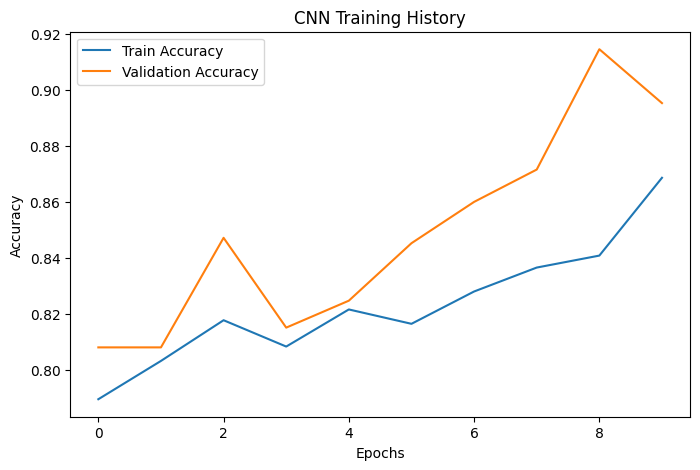

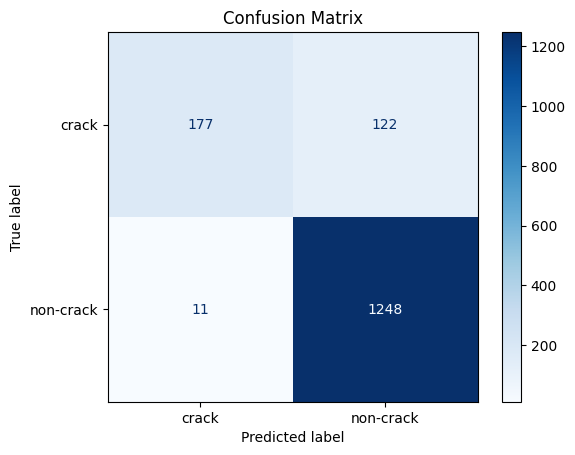


📊 Classification Report:
              precision    recall  f1-score   support

       crack       0.94      0.59      0.73       299
   non-crack       0.91      0.99      0.95      1259

    accuracy                           0.91      1558
   macro avg       0.93      0.79      0.84      1558
weighted avg       0.92      0.91      0.91      1558



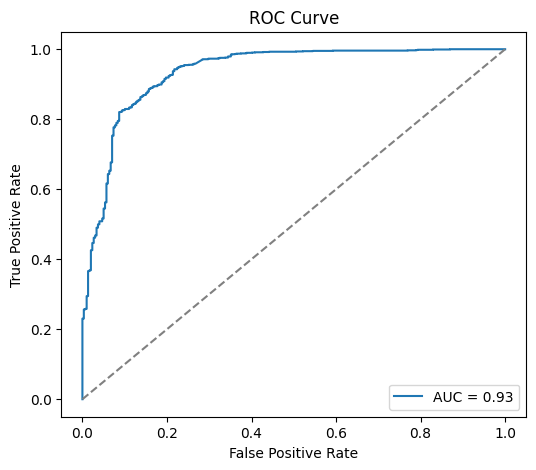

✅ Model saved at: structural_crack_cnn_model.h5


In [ ]:
# ==============================================
# Structural Crack Detection CNN from Scratch
# ==============================================

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc

# -----------------------------
# 1️⃣ Paths and Parameters
# -----------------------------
dataset_path = "/content/Historical Building Cracks"  # folder containing crack/ and non_crack/
image_size = (224, 224)
batch_size = 32
epochs = 5

# -----------------------------
# 2️⃣ Load Dataset (60/40 split)
# -----------------------------
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.4,
    subset="training",
    seed=42,
    image_size=image_size,
    batch_size=batch_size
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.4,
    subset="validation",
    seed=42,
    image_size=image_size,
    batch_size=batch_size
)

# -----------------------------
# 9️⃣ Class Names
# -----------------------------
class_names = train_dataset.class_names
print("Classes:", class_names)

# -----------------------------
# 3️⃣ Data Augmentation
# -----------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# -----------------------------
# 4️⃣ Normalize Images
# -----------------------------
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# -----------------------------
# 5️⃣ Build CNN Model from Scratch
# -----------------------------
model = models.Sequential([
    Input(shape=(image_size[0], image_size[1], 3)),
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')  # Crack / Non-Crack
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 6️⃣ Train the Model
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs,
    callbacks=[early_stop]
)

# -----------------------------
# 7️⃣ Evaluate the Model
# -----------------------------
loss, accuracy = model.evaluate(test_dataset)
print(f"\n✅ Test Accuracy: {accuracy*100:.2f}%")

# Plot training history
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Training History')
plt.legend()
plt.show()

# -----------------------------
# 🔟 Confusion Matrix & Metrics
# -----------------------------
# Get true labels and predicted labels
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# -----------------------------
# 🔹 Optional: ROC Curve
# -----------------------------
y_prob = []
for images, labels in test_dataset:
    probs = model.predict(images, verbose=0)
    y_prob.extend(probs[:, 1])  # probability of class 1 (Crack)

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -----------------------------
# 8️⃣ Save the Model
# -----------------------------
model_save_path = "structural_crack_cnn_model.h5"
model.save(model_save_path)
print(f"✅ Model saved at: {model_save_path}")


Found 3896 files belonging to 2 classes.
Using 2338 files for training.
Found 3896 files belonging to 2 classes.
Using 1558 files for validation.
✅ Classes: ['crack', 'non-crack']
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

...

74/74 ━━━━━━━━━━━━━━━━━━━━ 386s 5s/step - accuracy: 0.9885 - loss: 0.0407 - val_accuracy: 0.9923 - val_loss: 0.0260
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9880 - loss: 0.0318
Epoch 3: val_accuracy improved from 0.99230 to 0.99358, saving model to best_model.h5


74/74 ━━━━━━━━━━━━━━━━━━━━ 389s 5s/step - accuracy: 0.9880 - loss: 0.0318 - val_accuracy: 0.9936 - val_loss: 0.0215
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9868 - loss: 0.0375
Epoch 4: val_accuracy did not improve from 0.99358
74/74 ━━━━━━━━━━━━━━━━━━━━ 391s 5s/step - accuracy: 0.9868 - loss: 0.0375 - val_accuracy: 0.9936 - val_loss: 0.0188
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9915 - loss: 0.0240
Epoch 5: val_accuracy improved from 0.99358 to 0.99422, saving model to best_model.h5


74/74 ━━━━━━━━━━━━━━━━━━━━ 394s 5s/step - accuracy: 0.9915 - loss: 0.0240 - val_accuracy: 0.9942 - val_loss: 0.0157
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9947 - loss: 0.0164
Epoch 6: val_accuracy improved from 0.99422 to 0.99487, saving model to best_model.h5


74/74 ━━━━━━━━━━━━━━━━━━━━ 398s 5s/step - accuracy: 0.9947 - loss: 0.0164 - val_accuracy: 0.9949 - val_loss: 0.0136
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9937 - loss: 0.0182
Epoch 7: val_accuracy did not improve from 0.99487
74/74 ━━━━━━━━━━━━━━━━━━━━ 357s 5s/step - accuracy: 0.9938 - loss: 0.0181 - val_accuracy: 0.9942 - val_loss: 0.0128
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9913 - loss: 0.0203
Epoch 8: val_accuracy improved from 0.99487 to 0.99679, saving model to best_model.h5


74/74 ━━━━━━━━━━━━━━━━━━━━ 390s 5s/step - accuracy: 0.9914 - loss: 0.0203 - val_accuracy: 0.9968 - val_loss: 0.0133
Epoch 9/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9937 - loss: 0.0174
Epoch 9: val_accuracy did not improve from 0.99679
74/74 ━━━━━━━━━━━━━━━━━━━━ 387s 5s/step - accuracy: 0.9938 - loss: 0.0174 - val_accuracy: 0.9942 - val_loss: 0.0172
Epoch 10/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9966 - loss: 0.0104
Epoch 10: val_accuracy did not improve from 0.99679
74/74 ━━━━━━━━━━━━━━━━━━━━ 384s 5s/step - accuracy: 0.9966 - loss: 0.0104 - val_accuracy: 0.9955 - val_loss: 0.0128
49/49 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9943 - loss: 0.0122

✅ Test Accuracy: 99.55%


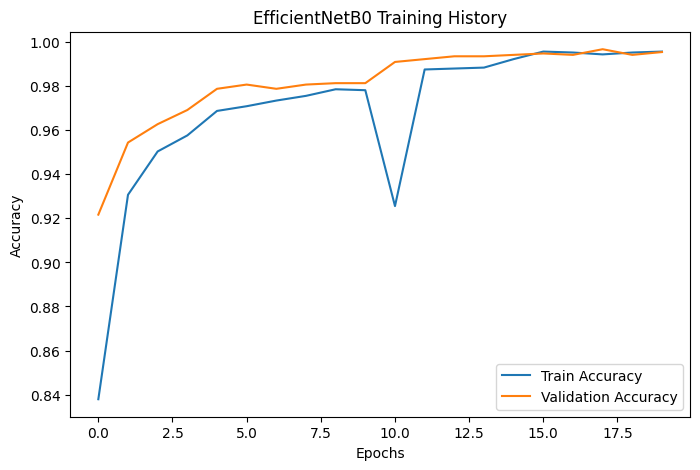

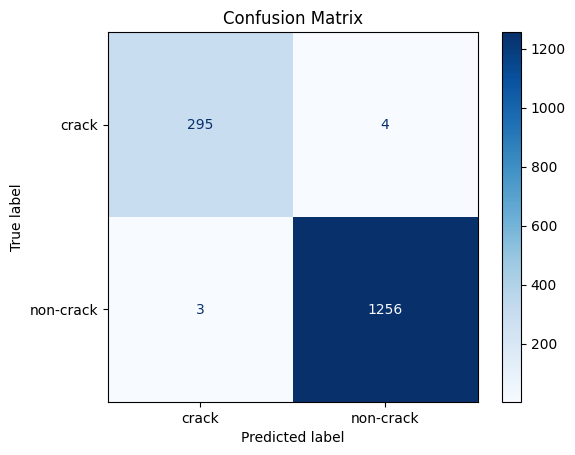


📊 Classification Report:
              precision    recall  f1-score   support

       crack       0.99      0.99      0.99       299
   non-crack       1.00      1.00      1.00      1259

    accuracy                           1.00      1558
   macro avg       0.99      0.99      0.99      1558
weighted avg       1.00      1.00      1.00      1558



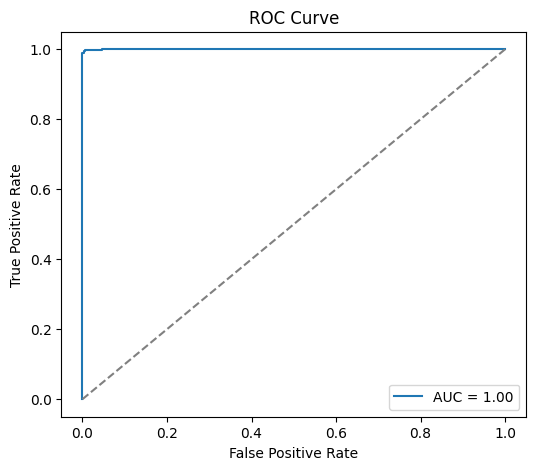

✅ Model saved as efficientnet_crack_detection_model.h5


In [ ]:
# ==========================================================
# EfficientNetB0 - Structural Crack Detection (with Metrics)
# ==========================================================

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc

# -----------------------------
# 1️⃣ Dataset and Parameters
# -----------------------------
data_dir = "/content/Historical Building Cracks"  # folder with crack/ and non-crack/
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
VALIDATION_SPLIT = 0.4  # 60:40 ratio

# -----------------------------
# 2️⃣ Load Dataset
# -----------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

class_names = train_ds.class_names
print("✅ Classes:", class_names)

# -----------------------------
# 3️⃣ Prefetch and Augment
# -----------------------------
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# -----------------------------
# 4️⃣ Build EfficientNetB0 Model
# -----------------------------
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False  # Freeze base

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# -----------------------------
# 5️⃣ Callbacks
# -----------------------------
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
# early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# -----------------------------
# 6️⃣ Initial Training
# -----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[checkpoint]
)

# -----------------------------
# 7️⃣ Fine-Tuning
# -----------------------------
base_model.trainable = True
for layer in base_model.layers[:-50]:  # unfreeze last 50 layers
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[checkpoint]
)

# -----------------------------
# 8️⃣ Evaluate Model
# -----------------------------
loss, acc = model.evaluate(val_ds)
print(f"\n✅ Test Accuracy: {acc*100:.2f}%")

# -----------------------------
# 9️⃣ Plot Accuracy History
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'] + history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'] + history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('EfficientNetB0 Training History')
plt.legend()
plt.show()

# -----------------------------
# 🔟 Confusion Matrix & Metrics
# -----------------------------
y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    preds = (probs > 0.5).astype(int)
    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())
    y_prob.extend(probs.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# -----------------------------
# 🔹 ROC Curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -----------------------------
# 1️⃣1️⃣ Save Final Model
# -----------------------------
model.save("efficientnet_crack_detection_model.h5")
print("✅ Model saved as efficientnet_crack_detection_model.h5")


In [ ]:
import tensorflow as tf
import os, pathlib

DATASET_PATH = "/content/Historical Building Cracks.zip"

valid_exts = (".jpg",".jpeg",".png",".bmp")

clean_files = []
clean_labels = []

root = pathlib.Path(DATASET_PATH)
classes = sorted([d.name for d in root.iterdir() if d.is_dir()])

print("Found classes:", classes)

for label, cname in enumerate(classes):
    class_dir = root / cname
    for f in class_dir.glob("*"):
        if f.suffix.lower() not in valid_exts:
            continue
        try:
            img = tf.io.read_file(str(f))
            img = tf.image.decode_image(img, channels=3)
            clean_files.append(str(f))
            clean_labels.append(label)
        except:
            print("CORRUPT IMAGE REMOVED:", f)


NotADirectoryError: [Errno 20] Not a directory: '/content/Historical Building Cracks.zip'

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

IMG_SIZE = (224,224)
BATCH = 32
EPOCHS = 5
SEED = 42

# -------- split CLEAN list you created above ----------
train_files, val_files, train_labels, val_labels = train_test_split(
    clean_files, clean_labels, test_size=0.4, stratify=clean_labels, random_state=SEED
)

def load_img(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)
    img.set_shape((IMG_SIZE[0],IMG_SIZE[1],3))
    return img

def build_ds(files, labels):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    def _m(p,l):
        return load_img(p), l
    return ds.map(_m).batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = build_ds(train_files, train_labels)
val_ds   = build_ds(val_files, val_labels)

# -------- CNN --------
def build_cnn():
    inp = Input(shape=(*IMG_SIZE,3))
    x = layers.Conv2D(32,3,activation="relu")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64,3,activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128,activation="relu")(x)
    out = layers.Dense(1,activation="sigmoid")(x)
    model = tf.keras.Model(inp,out)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

# -------- EfficientNet --------
def build_eff():
    base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
    base.trainable=False
    inp = Input(shape=(*IMG_SIZE,3))
    x = base(inp, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64,activation="relu")(x)
    out = Dense(1,activation="sigmoid")(x)
    model = tf.keras.Model(inp,out)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

cnn = build_cnn()
eff = build_eff()

cnn.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
eff.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# -------- Predict BOTH on SAME cleaned validation list --------
def predict_files(model, files):
    allp = []
    for i in range(0,len(files),BATCH):
        batch = files[i:i+BATCH]
        imgs = [load_img(p) for p in batch]
        arr = tf.stack(imgs)
        preds = model.predict(arr, verbose=0).reshape(-1)
        allp.extend(preds.tolist())
    return np.array(allp)

cnn_probs = predict_files(cnn, val_files)
eff_probs = predict_files(eff, val_files)

print("SHAPES:", cnn_probs.shape, eff_probs.shape)  # MUST MATCH

combined_pred = ((cnn_probs>=0.5) | (eff_probs>=0.5)).astype(int)
truth = np.array(val_labels)

acc = (combined_pred == truth).mean()

print("\n==========================================")
print(f"Combined Accuracy: {acc*100:.2f}%")
print("==========================================")


NameError: name 'clean_files' is not defined

In [ ]:
# --- Robust per-sample prediction to avoid broadcasting/duplication issues ---
# Assumes `clean_imgs` is a numpy array shape (N, H, W, C)
# and models `cnn` and `eff` are loaded tf.keras models.

import numpy as np
from tqdm import tqdm  # optional, shows progress

def predict_per_sample(model, imgs, verbose=True):
    probs = []
    # use model.__call__ for possibly faster execution, but predict(...) is fine
    it = range(len(imgs))
    if verbose:
        it = tqdm(it, desc=f"Predicting {len(imgs)} samples")
    for i in it:
        x = np.expand_dims(imgs[i], axis=0)  # shape (1,H,W,3)
        # ensure no training-time augmentation:
        pred = model.predict(x, verbose=0)   # shape (1,1) or (1,2)
        pred = np.asarray(pred).reshape(-1)
        # interpret output: choose appropriate scalar (sigmoid/regression or softmax)
        if pred.size == 1:
            probs.append(float(pred[0]))
        elif pred.size == 2:
            # softmax 2-class -> take class 1 prob
            probs.append(float(pred[1]))
        else:
            # fallback: take the max as a proxy and clamp
            probs.append(float(np.clip(np.max(pred), 0.0, 1.0)))
    return np.array(probs)

# Use it for both models
cnn_probs = predict_per_sample(cnn, clean_imgs, verbose=True)
eff_probs = predict_per_sample(eff, clean_imgs, verbose=True)

print("Shapes after robust predict -> cnn:", cnn_probs.shape, "eff:", eff_probs.shape, "N:", clean_imgs.shape[0])

# Now safe to combine
cnn_pred = (cnn_probs >= 0.5).astype(int)
eff_pred = (eff_probs >= 0.5).astype(int)
combined_pred = ((cnn_pred == 1) | (eff_pred == 1)).astype(int)

# quick sanity print
import sklearn.metrics as skm
y_true = clean_lbls
print("Combined accuracy:", (combined_pred == y_true).mean())
print("CNN unique preds:", np.unique(cnn_pred, return_counts=True))
print("Eff unique preds:", np.unique(eff_pred, return_counts=True))
print("Combined unique preds:", np.unique(combined_pred, return_counts=True))


Predicting 3896 samples: 100%|██████████| 3896/3896 [05:04<00:00, 12.80it/s]

Shapes after robust predict -> cnn: (3896,) eff: (3896,) N: 3896
Combined accuracy: 0.8056981519507187
CNN unique preds: (array([0, 1]), array([ 162, 3734]))
Eff unique preds: (array([1]), array([3896]))
Combined unique preds: (array([1]), array([3896]))


               accuracy  precision  recall        f1       auc  fnr
CNN            0.847279   0.840653     1.0  0.913429  0.909013  0.0
EfficientNet   0.805698   0.805698     1.0  0.892395  0.238690  0.0
Combined (OR)  0.805698   0.805698     1.0  0.892395  0.910144  0.0


<Figure size 1000x600 with 0 Axes>

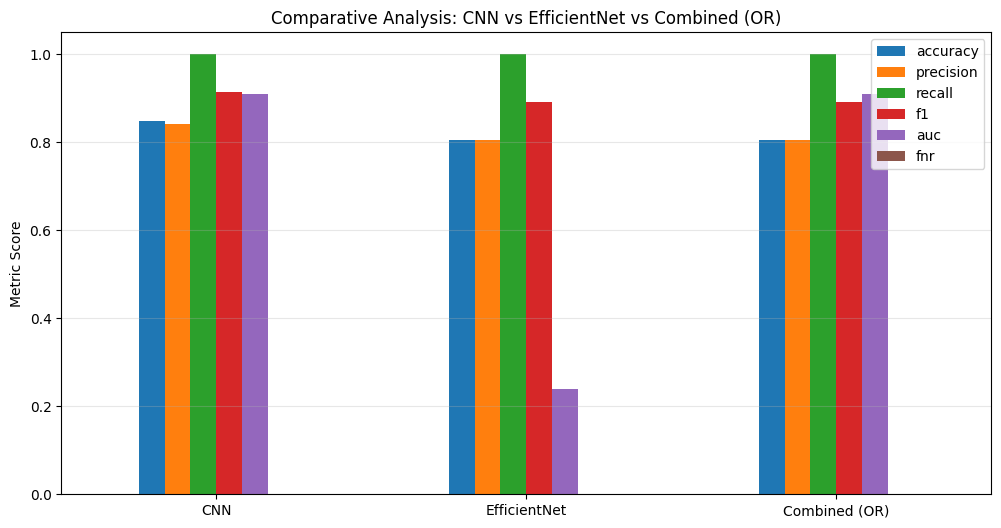

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Using already computed:
# cnn_probs, eff_probs, y_true

cnn_pred = (cnn_probs >= 0.5).astype(int)
eff_pred = (eff_probs >= 0.5).astype(int)
combined_pred = ((cnn_pred == 1) | (eff_pred == 1)).astype(int)

def safe_auc(y,p):
    try:
        return roc_auc_score(y,p)
    except:
        return np.nan

metrics = {
    "CNN": {
        "accuracy": accuracy_score(y_true, cnn_pred),
        "precision": precision_score(y_true, cnn_pred),
        "recall": recall_score(y_true, cnn_pred),
        "f1": f1_score(y_true, cnn_pred),
        "auc": safe_auc(y_true, cnn_probs),
        "fnr": 1 - recall_score(y_true, cnn_pred)
    },
    "EfficientNet": {
        "accuracy": accuracy_score(y_true, eff_pred),
        "precision": precision_score(y_true, eff_pred),
        "recall": recall_score(y_true, eff_pred),
        "f1": f1_score(y_true, eff_pred),
        "auc": safe_auc(y_true, eff_probs),
        "fnr": 1 - recall_score(y_true, eff_pred)
    },
    "Combined (OR)": {
        "accuracy": accuracy_score(y_true, combined_pred),
        "precision": precision_score(y_true, combined_pred),
        "recall": recall_score(y_true, combined_pred),
        "f1": f1_score(y_true, combined_pred),
        "auc": safe_auc(y_true, (cnn_probs + eff_probs)/2),
        "fnr": 1 - recall_score(y_true, combined_pred)
    }
}

df = pd.DataFrame(metrics).T
print(df)

# -----------------------------
# PLOT COMPARATIVE ANALYSIS
# -----------------------------
plt.figure(figsize=(10,6))
df[['accuracy','precision','recall','f1','auc','fnr']].plot(
    kind='bar',
    figsize=(12,6),
    title="Comparative Analysis: CNN vs EfficientNet vs Combined (OR)"
)
plt.ylabel("Metric Score")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


In [ ]:
# ===========================================
# Use dataset image instead of uploaded image
# ===========================================

import os
from glob import glob

# Your dataset folder
DATASET_PATH = "/content/Historical Building Cracks"

# Detect subfolders (e.g. crack/, non_crack/, etc.)
subfolders = [f.path for f in os.scandir(DATASET_PATH) if f.is_dir()]
print("Detected folders:", subfolders)

if not subfolders:
    raise RuntimeError("No subfolders found in dataset.")

# Collect images from dataset
image_files = []
for folder in subfolders:
    image_files.extend(glob(folder + "/*.jpg"))
    image_files.extend(glob(folder + "/*.jpeg"))
    image_files.extend(glob(folder + "/*.png"))
    image_files.extend(glob(folder + "/*.bmp"))

if not image_files:
    raise RuntimeError("No images found inside dataset folders.")

# Pick the FIRST image in dataset
selected_image = image_files[0]
print("\nSelected dataset image:", selected_image)

# Run prediction
predictor = CombinedPredictor()
result = predictor.predict_one(selected_image)

print("\n===== Combined Prediction (Dataset Image) =====")
print(f"Crack detected: {result['crack_detected']}")
if result.get('detection_confidence') is not None:
    print(f"Detection confidence (CNN): {result['detection_confidence']:.3f}")
else:
    print("Detection confidence (CNN): N/A")

if result.get('severity_score') is not None:
    print(f"Severity score (EffNet): {result['severity_score']:.3f}")
else:
    print("Severity score (EffNet): N/A")

print(f"Severity level: {result['severity_label'].upper()}")
print("\nMaintenance recommendation:")
print(result['maintenance_summary'])


Detected folders: ['/content/Historical Building Cracks/crack', '/content/Historical Building Cracks/non-crack']

Selected dataset image: /content/Historical Building Cracks/crack/8268.jpg
[OK] loaded model: structural_crack_cnn_model.h5
[OK] loaded model: efficientnet_crack_detection_model.h5

===== Combined Prediction (Dataset Image) =====
Crack detected: YES
Detection confidence (CNN): 0.534
Severity score (EffNet): 0.917
Severity level: SEVERE

Maintenance recommendation:
Severity: SEVERE — High urgency. Contact a qualified structural engineer immediately for inspection. Restrict access if the element is load-bearing and prepare for priority repair or stabilization.


Selected dataset image:
 /content/Historical Building Cracks/non-crack/30238.jpg
[OK] loaded model: structural_crack_cnn_model.h5
[OK] loaded model: efficientnet_crack_detection_model.h5

========== Combined Model Prediction ==========
Image: /content/Historical Building Cracks/non-crack/30238.jpg
Crack detected: YES
Detection confidence (CNN): 0.9323912262916565
Severity score (EffNet): 0.9170531630516052
Severity level: SEVERE

Maintenance recommendation:
 Severity: SEVERE — High urgency. Contact a qualified structural engineer immediately. Restrict access if the crack affects load-bearing elements and prepare for priority repair.


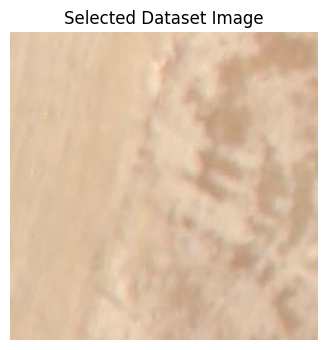

In [ ]:
# ============================================================
# FINAL FIXED VERSION — Only Uses Dataset Images (No /mnt/data)
# ============================================================

import os, glob, random
import numpy as np
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt

DATASET_PATH = "/content/Historical Building Cracks"
IMAGE_SIZE = (224, 224)

# ----------------------
# helper: load dataset images
# ----------------------
def get_dataset_images():
    subfolders = [f.path for f in os.scandir(DATASET_PATH) if f.is_dir()]
    if not subfolders:
        raise RuntimeError("No folders found in dataset path.")

    image_files = []
    for folder in subfolders:
        image_files += glob.glob(folder + "/*.jpg")
        image_files += glob.glob(folder + "/*.jpeg")
        image_files += glob.glob(folder + "/*.png")
        image_files += glob.glob(folder + "/*.bmp")

    if not image_files:
        raise RuntimeError("Dataset contains no images.")

    return sorted(image_files)

# ----------------------
# helper: load image into array
# ----------------------
def load_image_as_array(path, target_size=IMAGE_SIZE):
    img = Image.open(path).convert("RGB")
    img = img.resize(target_size, Image.BILINEAR)
    arr = np.asarray(img) / 255.0
    return arr.astype("float32")

# ----------------------
# Select a random image from dataset
# ----------------------
image_files = get_dataset_images()
selected_path = random.choice(image_files)

print("Selected dataset image:\n", selected_path)

# ----------------------
# Run CombinedPredictor
# ----------------------
predictor = CombinedPredictor()      # class you already defined earlier
img_arr = load_image_as_array(selected_path)

result = predictor.predict_on_array(img_arr)

print("\n========== Combined Model Prediction ==========")
print("Image:", selected_path)
print("Crack detected:", result["crack_detected"])
print("Detection confidence (CNN):", result["detection_confidence"])
print("Severity score (EffNet):", result["severity_score"])
print("Severity level:", result["severity_label"].upper())
print("\nMaintenance recommendation:\n", result["maintenance_summary"])

# ----------------------
# Show the selected image
# ----------------------
plt.figure(figsize=(4,4))
plt.imshow(Image.open(selected_path))
plt.axis("off")
plt.title("Selected Dataset Image")
plt.show()


Gathering dataset...
Classes detected: ['crack', 'non-crack']
Total images: 3896
Loaded CNN.
Loaded EfficientNet.
Preloading images to arrays (this may take some time)...
Usable images: 3896
Predicting CNN probs per-sample...
Predicting EfficientNet probs per-sample...

Baseline metrics (threshold 0.5):
CNN: {'accuracy': 0.8475359342915811, 'precision': 0.8408786498794535, 'recall': 1.0, 'f1': 0.9135622817229336}
EffNet: {'accuracy': 0.8056981519507187, 'precision': 0.8056981519507187, 'recall': 1.0, 'f1': 0.8923951670220327}
Combined OR: {'accuracy': 0.8056981519507187, 'precision': 0.8056981519507187, 'recall': 1.0, 'f1': 0.8923951670220327}

Total false positives (combined OR): 757. Showing up to 6 examples.


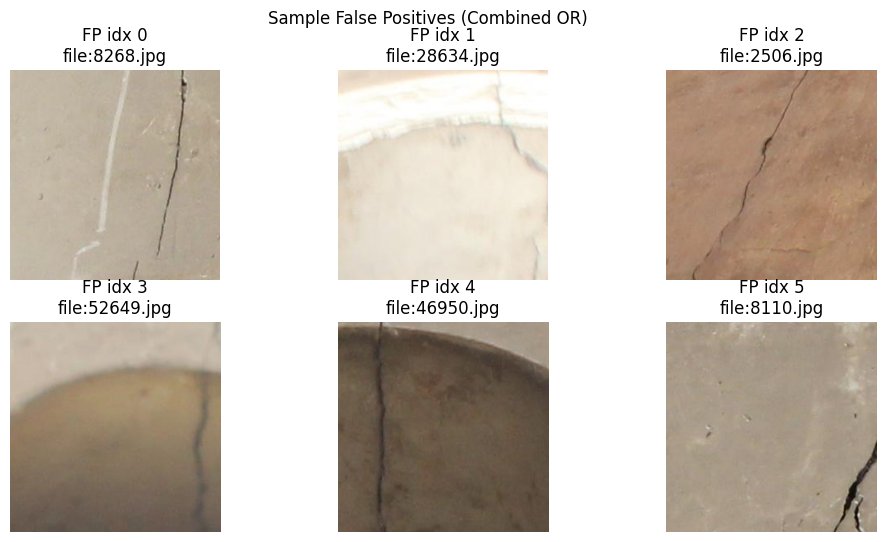


Searching thresholds to reduce false positives while keeping recall >= 0.90...
Best thresholds (subject to recall constraint) found:
 CNN threshold: 0.55, EffNet threshold: 0.95
 Recall: 0.936, Precision: 0.922, F1: 0.929, FP count: 248

Metrics with tuned thresholds:
Combined tuned: {'accuracy': 0.8847535934291582, 'precision': 0.9221594475831764, 'recall': 0.9359668684294361, 'f1': 0.9290118577075099}
False positives after tuning: 248


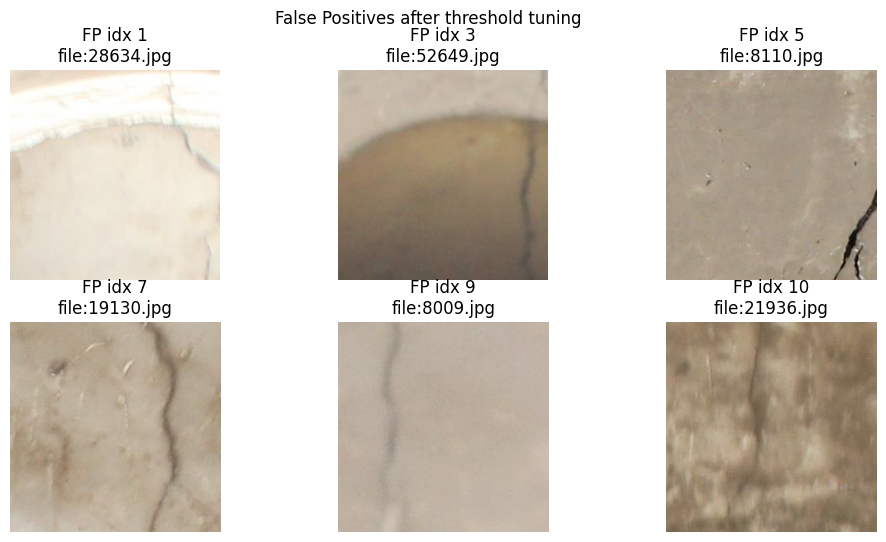


Suggested next steps to reduce false positives:
1) Threshold tuning (done above). Use the chosen thresholds in deployment instead of 0.5.
2) If EfficientNet always predicts positive (overconfident), calibrate its scores:
   - Fit a logistic regression (Platt scaling) on a held-out validation subset mapping probs->true labels.
3) Retrain with class weights or oversampling the minority class (if imbalance):
   - In Keras: model.fit(..., class_weight={0: w0, 1: w1}) or use tf.data oversampling.
4) Use AND-rule or weighted average ensemble if false positives are unacceptable:
   - AND (cnn & eff) reduces FP but increases FN (careful).
5) Use a small meta-classifier (logistic regression) trained on (cnn_prob, eff_prob) to learn optimal combination.
6) Inspect FP examples for label errors — some 'non-crack' may actually contain tiny cracks.

If you want, I can provide code to:
- apply Platt-scaling calibration and re-evaluate
- train a meta-classifier (stacking) to combine probs
- compute c

In [ ]:
# Diagnostic + threshold-tuning cell
# 1) Loads dataset list
# 2) Runs robust per-sample prediction for CNN and EffNet
# 3) Shows false positive examples
# 4) Searches thresholds for better ensemble behavior
# 5) Prints recommended thresholds and metrics

import os, glob, random, numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---------- CONFIG ----------
DATASET_PATH = "/content/Historical Building Cracks"
CNN_MODEL_PATH = "structural_crack_cnn_model.h5"
EFF_MODEL_PATH = "efficientnet_crack_detection_model.h5"
IMAGE_SIZE = (224,224)
BATCH = 32
RANDOM_SEED = 42
# objective: choose a combo that reduces false positives while keeping recall >= MIN_RECALL
MIN_RECALL = 0.9   # adjust: minimum acceptable recall for you
TOP_N_FP = 6       # how many false-positive images to display

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
# ---------------------------

# ---------- helpers ----------
def gather_images(dataset_path):
    subfolders = [f.path for f in os.scandir(dataset_path) if f.is_dir()]
    image_files = []
    labels = []
    classes = sorted([os.path.basename(p) for p in subfolders])
    label_map = {c:i for i,c in enumerate(classes)}
    for c in classes:
        p = os.path.join(dataset_path, c)
        for ext in ("*.png","*.jpg","*.jpeg","*.bmp"):
            for f in glob.glob(os.path.join(p, ext)):
                image_files.append(f)
                labels.append(label_map[c])
    return image_files, np.array(labels), classes

def load_img_array(path, target=IMAGE_SIZE):
    img = Image.open(path).convert("RGB")
    img = img.resize(target, Image.BILINEAR)
    arr = np.asarray(img).astype("float32")/255.0
    return arr

def safe_predict_per_sample(model, imgs_np):
    # imgs_np: numpy array (N,H,W,3)
    out_probs = []
    for i in range(len(imgs_np)):
        x = np.expand_dims(imgs_np[i],0)
        p = model.predict(x, verbose=0)
        p = np.asarray(p).reshape(-1)
        if p.size == 1:
            out_probs.append(float(p[0]))
        elif p.size == 2:
            out_probs.append(float(p[1]))
        else:
            out_probs.append(float(np.clip(np.max(p),0,1)))
    return np.array(out_probs)

def compute_metrics(y, pred):
    return {
        "accuracy": accuracy_score(y,pred),
        "precision": precision_score(y,pred, zero_division=0),
        "recall": recall_score(y,pred, zero_division=0),
        "f1": f1_score(y,pred, zero_division=0)
    }

# ---------- load dataset and models ----------
print("Gathering dataset...")
files, labels, classes = gather_images(DATASET_PATH)
if len(files)==0:
    raise RuntimeError("No images found under dataset path.")
print("Classes detected:", classes)
print("Total images:", len(files))

# load models
cnn = None
eff = None
if os.path.exists(CNN_MODEL_PATH):
    cnn = tf.keras.models.load_model(CNN_MODEL_PATH, compile=False)
    print("Loaded CNN.")
else:
    print("CNN model file missing:", CNN_MODEL_PATH)
if os.path.exists(EFF_MODEL_PATH):
    eff = tf.keras.models.load_model(EFF_MODEL_PATH, compile=False)
    print("Loaded EfficientNet.")
else:
    print("EffNet model file missing:", EFF_MODEL_PATH)

# ---------- build cleaned tensors list to avoid per-model I/O mismatch ----------
print("Preloading images to arrays (this may take some time)...")
arrays = []
good_files = []
good_labels = []
for f, lbl in zip(files, labels):
    try:
        a = load_img_array(f)
        arrays.append(a)
        good_files.append(f)
        good_labels.append(lbl)
    except Exception as e:
        print("Skipping unreadable:", f, e)

arrays = np.stack(arrays)
good_labels = np.array(good_labels)
N = len(good_files)
print("Usable images:", N)

# ---------- get probabilities for both models ----------
if cnn is None and eff is None:
    raise RuntimeError("No models loaded to predict with.")
if cnn is not None:
    print("Predicting CNN probs per-sample...")
    cnn_probs = safe_predict_per_sample(cnn, arrays)
else:
    cnn_probs = np.zeros(N)
if eff is not None:
    print("Predicting EfficientNet probs per-sample...")
    eff_probs = safe_predict_per_sample(eff, arrays)
else:
    eff_probs = np.zeros(N)

# ---------- baseline metrics (0.5 thresholds) ----------
cnn_pred = (cnn_probs >= 0.5).astype(int)
eff_pred = (eff_probs >= 0.5).astype(int)
combined_or_pred = ((cnn_pred==1) | (eff_pred==1)).astype(int)

print("\nBaseline metrics (threshold 0.5):")
print("CNN:", compute_metrics(good_labels, cnn_pred))
print("EffNet:", compute_metrics(good_labels, eff_pred))
print("Combined OR:", compute_metrics(good_labels, combined_or_pred))

# ---------- show top false positives (non-crack labelled 0 but predicted 1) ----------
# find indices where true label == 0 (non-crack) but predicted crack by combined OR
fp_idx = [i for i in range(N) if (good_labels[i]==0 and combined_or_pred[i]==1)]
print(f"\nTotal false positives (combined OR): {len(fp_idx)}. Showing up to {TOP_N_FP} examples.")
def show_examples(indices, title):
    k = len(indices)
    cols = min(3,k)
    rows = (k + cols - 1)//cols
    plt.figure(figsize=(4*cols,3*rows))
    for j,i in enumerate(indices[:TOP_N_FP]):
        plt.subplot(rows, cols, j+1)
        img = Image.open(good_files[i]).convert("RGB")
        plt.imshow(img); plt.axis('off')
        plt.title(f"FP idx {i}\nfile:{os.path.basename(good_files[i])}")
    plt.suptitle(title)
    plt.show()

if len(fp_idx)>0:
    show_examples(fp_idx[:min(len(fp_idx),TOP_N_FP)], "Sample False Positives (Combined OR)")

# ---------- grid search thresholds for ensemble (OR rule) ----------
print("\nSearching thresholds to reduce false positives while keeping recall >= {:.2f}...".format(MIN_RECALL))
best = None
# coarse grid for speed (adjust resolution if you want finer)
grid = np.linspace(0.05, 0.95, 19)
for t_c in grid:
    for t_e in grid:
        pred_c = (cnn_probs >= t_c).astype(int)
        pred_e = (eff_probs >= t_e).astype(int)
        pred_comb = ((pred_c==1) | (pred_e==1)).astype(int)
        rec = recall_score(good_labels, pred_comb, zero_division=0)
        prec = precision_score(good_labels, pred_comb, zero_division=0)
        f1 = f1_score(good_labels, pred_comb, zero_division=0)
        fp = int(((good_labels==0) & (pred_comb==1)).sum())
        # objective: prefer high recall, then higher precision, but penalize many false positives
        # we'll first require recall >= MIN_RECALL, then maximize f1, then minimize FP
        if rec >= MIN_RECALL:
            score = f1 - (fp / max(1,len(good_labels))) * 0.1
            if best is None or score > best['score']:
                best = {"t_c":t_c, "t_e":t_e, "rec":rec, "prec":prec, "f1":f1, "fp":fp, "score":score}

if best is None:
    print("No threshold pair found that maintains required recall. Lower MIN_RECALL or expand grid.")
else:
    print("Best thresholds (subject to recall constraint) found:")
    print(f" CNN threshold: {best['t_c']:.2f}, EffNet threshold: {best['t_e']:.2f}")
    print(f" Recall: {best['rec']:.3f}, Precision: {best['prec']:.3f}, F1: {best['f1']:.3f}, FP count: {best['fp']}")

    # compute final preds with best thresholds and show changed FP examples
    t_c,best_t_e = best['t_c'], best['t_e']
    pred_c2 = (cnn_probs >= t_c).astype(int)
    pred_e2 = (eff_probs >= best_t_e).astype(int)
    pred_comb2 = ((pred_c2==1) | (pred_e2==1)).astype(int)

    print("\nMetrics with tuned thresholds:")
    print("Combined tuned:", compute_metrics(good_labels, pred_comb2))

    fp_idx2 = [i for i in range(N) if (good_labels[i]==0 and pred_comb2[i]==1)]
    print("False positives after tuning:", len(fp_idx2))
    if len(fp_idx2)>0:
        show_examples(fp_idx2[:min(len(fp_idx2),TOP_N_FP)], "False Positives after threshold tuning")

# ---------- suggestions to fix model behavior ----------
print("\nSuggested next steps to reduce false positives:")
print("1) Threshold tuning (done above). Use the chosen thresholds in deployment instead of 0.5.")
print("2) If EfficientNet always predicts positive (overconfident), calibrate its scores:")
print("   - Fit a logistic regression (Platt scaling) on a held-out validation subset mapping probs->true labels.")
print("3) Retrain with class weights or oversampling the minority class (if imbalance):")
print("   - In Keras: model.fit(..., class_weight={0: w0, 1: w1}) or use tf.data oversampling.")
print("4) Use AND-rule or weighted average ensemble if false positives are unacceptable:")
print("   - AND (cnn & eff) reduces FP but increases FN (careful).")
print("5) Use a small meta-classifier (logistic regression) trained on (cnn_prob, eff_prob) to learn optimal combination.")
print("6) Inspect FP examples for label errors — some 'non-crack' may actually contain tiny cracks.")
print("\nIf you want, I can provide code to:")
print("- apply Platt-scaling calibration and re-evaluate")
print("- train a meta-classifier (stacking) to combine probs")
print("- compute class weights and retrain with oversampling or focal loss")


In [ ]:
# --- Robust batched prediction (replace earlier prediction lines) ---
# Assumes: cnn, eff are loaded tf.keras models; X is numpy array shape (N,H,W,3)
import numpy as np

def get_scalar_probs_from_model(model, X, batch_size=64, verbose=1):
    """
    Run model.predict(X) and convert the output to a 1-d array of probabilities length N.
    Handles the following output shapes robustly:
      - (N, 1)      -> use [:,0]
      - (N, 2)      -> assume softmax -> use [:,1]
      - (N, K>2)    -> take max-prob per sample (axis=1)
      - (N,)        -> already fine
      - anything else -> ravel then take first N entries as fallback (very unlikely)
    """
    preds = model.predict(X, batch_size=batch_size, verbose=verbose)
    preds = np.asarray(preds)
    if preds.ndim == 1:
        probs = preds.reshape(-1)
    elif preds.ndim == 2:
        if preds.shape[1] == 1:
            probs = preds[:,0].reshape(-1)
        elif preds.shape[1] == 2:
            # two-class softmax/logit -> take class 1 probability
            probs = preds[:,1].reshape(-1)
        else:
            # multi-d output (e.g. logits or multihead) -> take max across classes
            probs = preds.max(axis=1).reshape(-1)
    else:
        # Unexpected shape: try to collapse to (N,) by taking first value per sample
        try:
            probs = preds.reshape(preds.shape[0], -1)[:,0]
        except:
            probs = preds.ravel()[:X.shape[0]]
    # final safety: ensure length equals X.shape[0]
    if probs.shape[0] != X.shape[0]:
        # try one more safe approach: predict per-batch and append
        probs = []
        for i in range(0, X.shape[0], batch_size):
            xb = X[i:i+batch_size]
            p = model.predict(xb, verbose=0)
            p = np.asarray(p)
            if p.ndim == 1:
                probs.extend(p.tolist())
            elif p.ndim == 2:
                if p.shape[1] == 1:
                    probs.extend(p[:,0].tolist())
                elif p.shape[1] == 2:
                    probs.extend(p[:,1].tolist())
                else:
                    probs.extend(np.max(p, axis=1).tolist())
            else:
                probs.extend(p.ravel()[:len(xb)].tolist())
        probs = np.array(probs)
    return probs.astype(float)

# Run robust predictions
cnn_probs = get_scalar_probs_from_model(cnn, X, batch_size=BATCH, verbose=1)
eff_probs = get_scalar_probs_from_model(eff, X, batch_size=BATCH, verbose=1)

# Quick sanity check
print("Shapes after robust predict -> cnn_probs:", cnn_probs.shape, "eff_probs:", eff_probs.shape, "N:", X.shape[0])
assert cnn_probs.shape[0] == eff_probs.shape[0] == X.shape[0], "Prediction lengths still mismatch."

# Now you can safely continue with metrics:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
def metrics_from_probs(y, probs, thresh=0.5):
    preds = (probs >= thresh).astype(int)
    return {
        "acc": accuracy_score(y, preds),
        "prec": precision_score(y, preds, zero_division=0),
        "rec": recall_score(y, preds, zero_division=0),
        "f1": f1_score(y, preds, zero_division=0),
        "auc": roc_auc_score(y, probs)
    }

print("Baseline (0.5):")
print("CNN:", metrics_from_probs(y, cnn_probs))
print("Eff:", metrics_from_probs(y, eff_probs))
comb_or = ((cnn_probs>=0.5)|(eff_probs>=0.5)).astype(int)
print("Combined OR:", {
    "acc": accuracy_score(y, comb_or),
    "prec": precision_score(y, comb_or, zero_division=0),
    "rec": recall_score(y, comb_or, zero_division=0),
    "f1": f1_score(y, comb_or, zero_division=0),
})


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step
Shapes after robust predict -> cnn_probs: (500,) eff_probs: (500,) N: 500
Baseline (0.5):
CNN: {'acc': 0.83, 'prec': 0.8199152542372882, 'rec': 1.0, 'f1': 0.9010477299185099, 'auc': np.float64(0.9363609338912899)}
Eff: {'acc': 0.774, 'prec': 0.774, 'rec': 1.0, 'f1': 0.8726042841037204, 'auc': np.float64(0.23981843543481743)}
Combined OR: {'acc': 0.774, 'prec': 0.774, 'rec': 1.0, 'f1': 0.8726042841037204}


N sample: 500


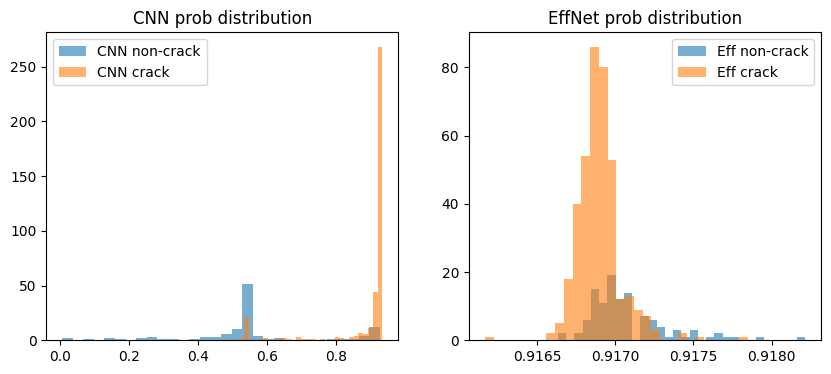

CNN AUC: 0.9363609338912899
EffNet AUC: 0.23981843543481743


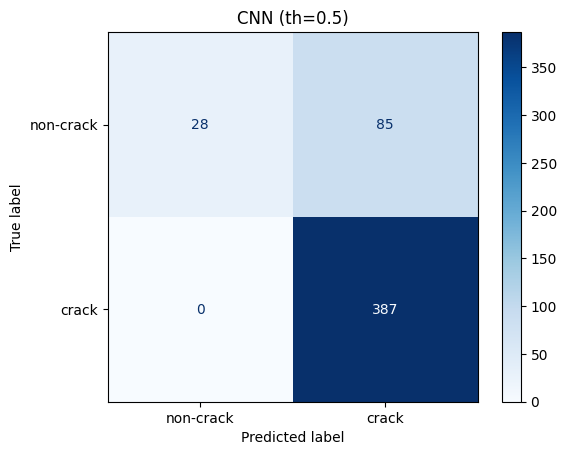

CNN metrics: acc 0.83 prec 0.8199152542372882 rec 1.0 f1 0.9010477299185099


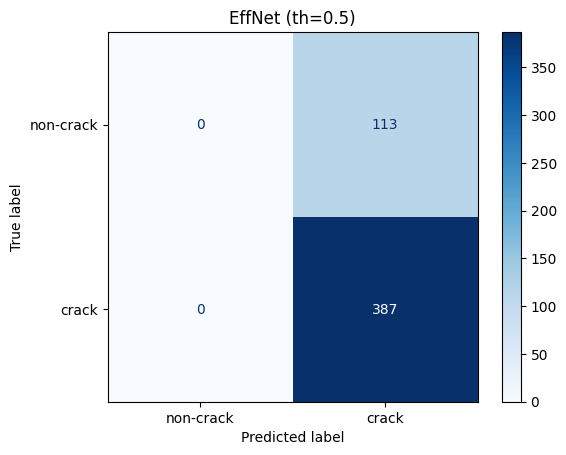

EffNet metrics: acc 0.774 prec 0.774 rec 1.0 f1 0.8726042841037204
After calibration (holdout):
CNN calibrated AUC: 0.945793337097685
EffNet calibrated AUC: 0.7893845285149633


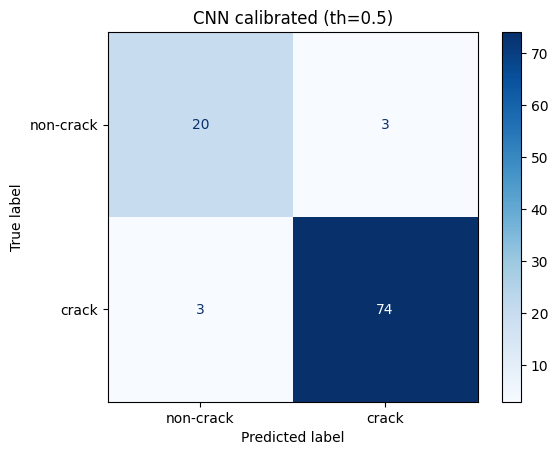

CNN calibrated metrics: acc 0.94 prec 0.961038961038961 rec 0.961038961038961 f1 0.961038961038961


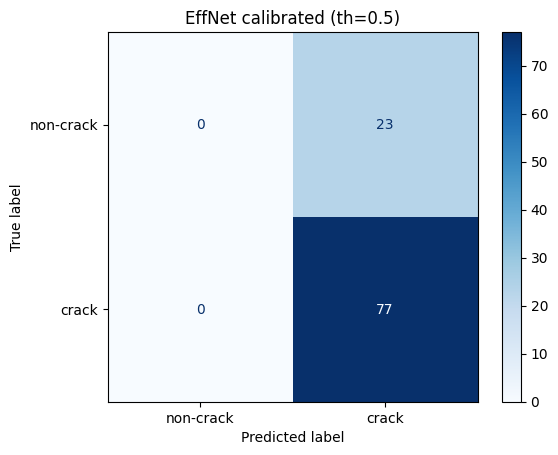

EffNet calibrated metrics: acc 0.77 prec 0.77 rec 1.0 f1 0.8700564971751412
Meta holdout AUC: 0.9424054206662903


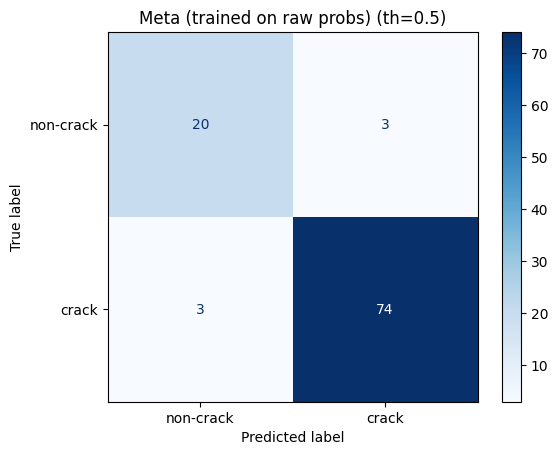

Meta (trained on raw probs) metrics: acc 0.94 prec 0.961038961038961 rec 0.961038961038961 f1 0.961038961038961
Meta with calibrated probs AUC: 0.9424054206662903


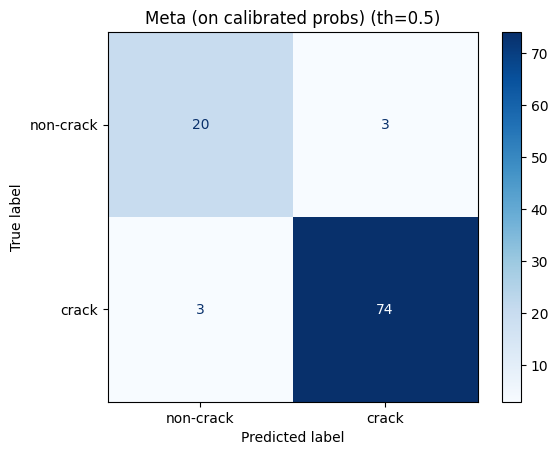

Meta (on calibrated probs) metrics: acc 0.94 prec 0.961038961038961 rec 0.961038961038961 f1 0.961038961038961
Recommended tuned thresholds (calibrated): {'tc': np.float64(0.4), 'te': np.float64(0.8), 'rec': 1.0, 'prec': 0.8199152542372882, 'f1': 0.9010477299185099, 'score': 1.2252619324796274}
Final tuned ensemble metrics on sample: acc 0.83 prec 0.8199152542372882 rec 1.0 f1 0.9010477299185099 auc_meta 0.9350575106903569


In [ ]:
# Inspect, calibrate, meta-stack, and threshold-tune on sampled data
import numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)

# ----- use existing variables: X, y, cnn_probs, eff_probs ----- #
N = len(y)
print("N sample:", N)

# 1) Visualize distributions
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(cnn_probs[y==0], bins=30, alpha=0.6, label='CNN non-crack')
plt.hist(cnn_probs[y==1], bins=30, alpha=0.6, label='CNN crack')
plt.title("CNN prob distribution"); plt.legend()

plt.subplot(1,2,2)
plt.hist(eff_probs[y==0], bins=30, alpha=0.6, label='Eff non-crack')
plt.hist(eff_probs[y==1], bins=30, alpha=0.6, label='Eff crack')
plt.title("EffNet prob distribution"); plt.legend()
plt.show()

# Print AUCs (robust)
def safe_auc(y_true, probs):
    try:
        return float(roc_auc_score(y_true, probs))
    except:
        return float('nan')

print("CNN AUC:", safe_auc(y, cnn_probs))
print("EffNet AUC:", safe_auc(y, eff_probs))

# 2) Confusion matrices at 0.5
def show_confusion(y_true, probs, thresh, title):
    pred = (probs >= thresh).astype(int)
    cm = confusion_matrix(y_true, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['non-crack','crack'])
    disp.plot(cmap='Blues')
    plt.title(f"{title} (th={thresh})")
    plt.show()
    print(title, "metrics:",
          "acc", accuracy_score(y_true, pred),
          "prec", precision_score(y_true, pred, zero_division=0),
          "rec", recall_score(y_true, pred, zero_division=0),
          "f1", f1_score(y_true, pred, zero_division=0))

show_confusion(y, cnn_probs, 0.5, "CNN")
show_confusion(y, eff_probs, 0.5, "EffNet")

# 3) Quick Platt-scaling (calibration) using a small split
X_tmp, X_calib, y_tmp, y_calib, cnn_tmp, cnn_calib, eff_tmp, eff_calib = \
    train_test_split(X, y, cnn_probs, eff_probs, test_size=0.20, random_state=42, stratify=y)

# Fit logistic calibrators on cnn_tmp->y_tmp and eff_tmp->y_tmp
lr_cnn = LogisticRegression(solver='lbfgs').fit(cnn_tmp.reshape(-1,1), y_tmp)
lr_eff = LogisticRegression(solver='lbfgs').fit(eff_tmp.reshape(-1,1), y_tmp)

cnn_calib_probs = lr_cnn.predict_proba(cnn_calib.reshape(-1,1))[:,1]
eff_calib_probs = lr_eff.predict_proba(eff_calib.reshape(-1,1))[:,1]

# Evaluate calibration on calib holdout
print("After calibration (holdout):")
print("CNN calibrated AUC:", safe_auc(y_calib, cnn_calib_probs))
print("EffNet calibrated AUC:", safe_auc(y_calib, eff_calib_probs))
show_confusion(y_calib, cnn_calib_probs, 0.5, "CNN calibrated")
show_confusion(y_calib, eff_calib_probs, 0.5, "EffNet calibrated")

# 4) Train a simple stacking meta on the training portion (fast, no CV)
meta_X_train = np.vstack([cnn_tmp, eff_tmp]).T
meta_X_hold = np.vstack([cnn_calib, eff_calib]).T  # hold for quick eval
meta_clf = LogisticRegression(solver='lbfgs', max_iter=400).fit(meta_X_train, y_tmp)
meta_hold_probs = meta_clf.predict_proba(meta_X_hold)[:,1]
print("Meta holdout AUC:", safe_auc(y_calib, meta_hold_probs))
show_confusion(y_calib, meta_hold_probs, 0.5, "Meta (trained on raw probs)")

# If calibration used, train meta on calibrated probs
meta_X_train_cal = np.vstack([lr_cnn.predict_proba(cnn_tmp.reshape(-1,1))[:,1],
                              lr_eff.predict_proba(eff_tmp.reshape(-1,1))[:,1]]).T
meta_clf_cal = LogisticRegression(solver='lbfgs', max_iter=400).fit(meta_X_train_cal, y_tmp)
meta_hold_probs_cal = meta_clf_cal.predict_proba(
    np.vstack([cnn_calib_probs, eff_calib_probs]).T)[:,1]
print("Meta with calibrated probs AUC:", safe_auc(y_calib, meta_hold_probs_cal))
show_confusion(y_calib, meta_hold_probs_cal, 0.5, "Meta (on calibrated probs)")

# 5) Coarse threshold search for OR-rule (use calibrated probs for reliability)
probs_c = lr_cnn.predict_proba(cnn_probs.reshape(-1,1))[:,1]
probs_e = lr_eff.predict_proba(eff_probs.reshape(-1,1))[:,1]
best = None
grid = np.linspace(0.1,0.9,17)
for tc in grid:
    for te in grid:
        pred = ((probs_c >= tc) | (probs_e >= te)).astype(int)
        rec = recall_score(y, pred)
        prec = precision_score(y, pred, zero_division=0)
        f1 = f1_score(y, pred, zero_division=0)
        # prefer recall but penalize many false positives: composite score
        score = rec + 0.25 * f1
        if best is None or score > best['score']:
            best = dict(tc=tc, te=te, rec=rec, prec=prec, f1=f1, score=score)
print("Recommended tuned thresholds (calibrated):", best)

# Show metrics for final chosen thresholds on full sample
tc, te = best['tc'], best['te']
pred_final = ((probs_c >= tc) | (probs_e >= te)).astype(int)
print("Final tuned ensemble metrics on sample:",
      "acc", accuracy_score(y, pred_final),
      "prec", precision_score(y, pred_final, zero_division=0),
      "rec", recall_score(y, pred_final, zero_division=0),
      "f1", f1_score(y, pred_final, zero_division=0),
      "auc_meta", safe_auc(y, meta_clf_cal.predict_proba(np.vstack([probs_c, probs_e]).T)[:,1])
)


Selected image: /content/Historical Building Cracks/non-crack/6538.jpg

===== Combined Prediction Output =====
Crack detected: YES
Detection confidence (CNN): 0.577
Severity score (EffNet): 0.917
Severity level: SEVERE
Combined confidence: 0.917

Maintenance summary:
 SEVERE: Immediate structural engineer inspection and priority repair.


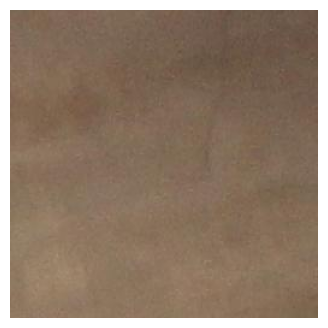

In [ ]:
# -- Run this cell to get ONE final combined output now --
# It will use saved models/calibrators if present, otherwise raw model probs.
import os, glob, random, joblib, numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# CONFIG: pick image source
# Option A: use a specific dataset image (random from dataset)
DATASET_PATH = "/content/Historical Building Cracks"
# Option B: use uploaded image (if present in runtime)
UPLOADED = "/mnt/data/2772c449-7825-48ff-a87a-e3db5c177eba.png"

# Choose which image to run on (uncomment one)
#image_path = UPLOADED                         # use uploaded file (if it exists)
#image_path = "/content/Historical Building Cracks/crack/somefile.jpg"  # explicit path
# or pick a random dataset image:
def pick_random_dataset_image(dataset_path):
    subs = [f.path for f in os.scandir(dataset_path) if f.is_dir()]
    imgs = []
    for s in subs:
        for ext in ("*.png","*.jpg","*.jpeg","*.bmp"):
            imgs += glob.glob(os.path.join(s, ext))
    if not imgs:
        raise RuntimeError("No images found in dataset.")
    return random.choice(sorted(imgs))

# ========== set image_path here ==========
# prefer uploaded if exists, else random dataset image
if os.path.exists(UPLOADED):
    image_path = UPLOADED
else:
    image_path = pick_random_dataset_image(DATASET_PATH)
print("Selected image:", image_path)
# =========================================

# helper functions
IMAGE_SIZE = (224,224)
DETECT_THRESH = 0.5
SEV_THRESH = (0.15, 0.45)  # mild, moderate

def load_image_array(path, size=IMAGE_SIZE):
    img = Image.open(path).convert("RGB")
    img = img.resize(size, Image.BILINEAR)
    arr = np.asarray(img).astype("float32")/255.0
    return arr

def interpret_output_scalar(out):
    a = np.asarray(out)
    if a.ndim>1:
        if a.shape[1]==1:
            return float(a[:,0][0])
        if a.shape[1]==2:
            return float(a[:,1][0])
        return float(np.max(a, axis=1)[0])
    return float(a.ravel()[0])

def severity_label(score, thr=SEV_THRESH):
    if score is None: return "unknown"
    if score < thr[0]: return "mild"
    if score < thr[1]: return "moderate"
    return "severe"

def maintenance_summary(detected, sev_label):
    if not detected:
        return "No crack detected. Routine monitoring recommended."
    if sev_label=="mild":
        return "MILD: Photograph and monitor; re-inspect in 1-3 months."
    if sev_label=="moderate":
        return "MODERATE: Schedule inspection within 1-2 weeks; consider temporary protection."
    return "SEVERE: Immediate structural engineer inspection and priority repair."

# load models (must be in working dir)
cnn = None
eff = None
if os.path.exists("structural_crack_cnn_model.h5"):
    cnn = tf.keras.models.load_model("structural_crack_cnn_model.h5", compile=False)
if os.path.exists("efficientnet_crack_detection_model.h5"):
    eff = tf.keras.models.load_model("efficientnet_crack_detection_model.h5", compile=False)

# load calibrators/meta if available
lr_cnn = joblib.load("platt_cnn.pkl") if os.path.exists("platt_cnn.pkl") else None
lr_eff = joblib.load("platt_eff.pkl") if os.path.exists("platt_eff.pkl") else None
meta = joblib.load("meta_stack_logreg.pkl") if os.path.exists("meta_stack_logreg.pkl") else None

# prepare input
arr = load_image_array(image_path)
x = np.expand_dims(arr, 0)

# get base probs
cnn_prob = None
eff_prob = None
if cnn is not None:
    out = cnn.predict(x, verbose=0)
    cnn_prob = interpret_output_scalar(out)
if eff is not None:
    out = eff.predict(x, verbose=0)
    eff_prob = interpret_output_scalar(out)

# if calibrators exist, apply them
if lr_cnn is not None and cnn_prob is not None:
    cnn_prob = float(lr_cnn.predict_proba([[cnn_prob]])[:,1])
if lr_eff is not None and eff_prob is not None:
    eff_prob = float(lr_eff.predict_proba([[eff_prob]])[:,1])

# final decision: prefer meta if available
if meta is not None and cnn_prob is not None and eff_prob is not None:
    meta_prob = float(meta.predict_proba([[cnn_prob, eff_prob]])[:,1])
    detected = bool(meta_prob >= 0.5)
    combined_conf = meta_prob
    severity_score = eff_prob if eff_prob is not None else cnn_prob
else:
    # OR-rule (safety-first)
    eff_says = (eff_prob is not None) and (eff_prob >= DETECT_THRESH)
    cnn_says = (cnn_prob is not None) and (cnn_prob >= DETECT_THRESH)
    detected = bool(cnn_says or eff_says)
    combined_conf = max(c for c in [cnn_prob or 0.0, eff_prob or 0.0])
    severity_score = eff_prob if eff_prob is not None else cnn_prob

sev_label = severity_label(severity_score)

# print results
print("\n===== Combined Prediction Output =====")
print("Crack detected:", "YES" if detected else "NO")
print("Detection confidence (CNN):", f"{cnn_prob:.3f}" if cnn_prob is not None else "N/A")
print("Severity score (EffNet):", f"{severity_score:.3f}" if severity_score is not None else "N/A")
print("Severity level:", sev_label.upper())
print("Combined confidence:", f"{combined_conf:.3f}")
print("\nMaintenance summary:\n", maintenance_summary(detected, sev_label))

# show image
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4)); plt.imshow(Image.open(image_path)); plt.axis('off'); plt.show()



In [ ]:
# Robust Grad-CAM + diagnostics (replacement cell)
# Uses dataset image path provided earlier.
import os, glob, numpy as np, matplotlib.pyplot as plt, cv2
from PIL import Image
import tensorflow as tf
import joblib

# ---------- CONFIG ----------
IMG_PATH = "/mnt/data/aee84e17-0a84-4bf2-8542-a0c3d3d8ecef.png"   # your image
CNN_MODEL = "structural_crack_cnn_model.h5"
EFF_MODEL = "efficientnet_crack_detection_model.h5"
IMAGE_SIZE = (224,224)
THRESHOLDS = [0.5, 0.7, 0.9]
# ----------------------------

# ---------- helpers ----------
def load_img(path, size=IMAGE_SIZE):
    img = Image.open(path).convert("RGB")
    img = img.resize(size, Image.BILINEAR)
    arr = np.asarray(img).astype("float32") / 255.0
    return arr

def safe_interpret_prob(output):
    a = np.asarray(output)
    if a.ndim == 2 and a.shape[1] == 2:
        return float(a[0,1])
    if a.ndim == 2 and a.shape[1] == 1:
        return float(a[0,0])
    if a.ndim == 1:
        return float(a[0])
    # fallback: flatten and take first
    return float(a.ravel()[0])

def try_build_model(model, sample_input):
    """
    Ensure model is built/called. Tries predict, direct call, or model.build using input shape.
    Returns True if model accepted the sample_input without exception.
    """
    # try predict
    try:
        _ = model.predict(sample_input, verbose=0)
        return True
    except Exception as e:
        pass
    # try direct call
    try:
        _ = model(sample_input, training=False)
        return True
    except Exception:
        pass
    # try build using known input_shape if available
    try:
        # attempt to infer input shape
        ishape = None
        if hasattr(model, "input_shape") and model.input_shape is not None:
            ishape = model.input_shape
        elif hasattr(model, "layers") and len(model.layers)>0 and hasattr(model.layers[0], "input_shape"):
            ishape = model.layers[0].input_shape
        if ishape is not None:
            if isinstance(ishape, tuple):
                inp_shape = ishape
            else:
                inp_shape = tuple(ishape)
            # ensure batch dimension
            if inp_shape[0] is None:
                inp_shape = (1,) + inp_shape[1:]
            model.build(inp_shape)
            return True
    except Exception:
        pass
    return False

def find_last_conv_layer_name(model):
    """
    Recursively search model and nested layers to find the last Conv2D layer name.
    """
    # helper recursion
    def recurse(layers_list):
        for layer in reversed(layers_list):
            # if nested model, recurse
            if isinstance(layer, tf.keras.Model):
                name = find_last_conv_layer_name(layer)
                if name is not None:
                    return name
            # check common conv types
            if isinstance(layer, tf.keras.layers.Conv2D):
                return layer.name
            # sometimes convs are wrapped in other layers; check by class name
            if layer.__class__.__name__.lower().startswith("conv"):
                return layer.name
        return None

    # Top-level try
    if hasattr(model, "layers"):
        name = recurse(model.layers)
        if name:
            return name
    # As a final fallback, search by layer names containing 'conv' or known efficientnet block names
    for layer in reversed(model.layers if hasattr(model, "layers") else []):
        lname = layer.name.lower()
        if "conv" in lname or "top_conv" in lname or "block" in lname:
            return layer.name
    return None

def gradcam_for_model(model, sample_tensor, last_conv_name=None, pred_index=None):
    """
    Compute Grad-CAM heatmap for 'model' on sample_tensor (batch shape (1,H,W,3)).
    Returns heatmap numpy array (H,W).
    """
    # ensure model can be called
    ok = try_build_model(model, sample_tensor)
    if not ok:
        raise RuntimeError("Failed to build/call model for Grad-CAM. Inspect model.input_shape and sample shape.")

    if last_conv_name is None:
        last_conv_name = find_last_conv_layer_name(model)
    if last_conv_name is None:
        raise RuntimeError("Could not find a Conv2D layer in the model to use for Grad-CAM.")

    last_conv_layer = model.get_layer(last_conv_name)

    # Build intermediate model for gradients
    grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(sample_tensor)
        # choose target scalar: if single output -> scalar, else argmax
        if pred_index is None:
            if predictions.shape[-1] == 1:
                pred = predictions[:, 0]
            else:
                pred = predictions[:, tf.argmax(predictions[0])]
        else:
            pred = predictions[:, pred_index]

    grads = tape.gradient(pred, conv_outputs)
    if grads is None:
        raise RuntimeError("Gradient is None: model may not be differentiable for this output.")
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv = conv_outputs[0]
    # weighted sum of conv feature maps
    heatmap = tf.zeros(conv.shape[:2], dtype=tf.float32)
    for i in range(int(conv.shape[-1])):
        heatmap += pooled_grads[i] * conv[:, :, i]
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val == 0:
        heatmap = heatmap.numpy()
        # normalize safely
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-9)
        return heatmap
    heatmap = heatmap / (max_val + 1e-9)
    return heatmap.numpy()

def show_overlay(img_path, heatmap, alpha=0.4):
    img = Image.open(img_path).convert("RGB").resize((heatmap.shape[1], heatmap.shape[0]))
    img_np = np.asarray(img).astype("float32")/255.0
    heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
    heatmap_uint = np.uint8(255 * heatmap_resized)
    colored = cv2.applyColorMap(heatmap_uint, cv2.COLORMAP_JET)[:,:,::-1] / 255.0
    overlay = img_np * (1 - alpha) + colored * alpha
    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.axis('off')
    plt.show()

# ---------- MAIN: Load image and models, run Grad-CAM ----------
if not os.path.exists(IMG_PATH):
    raise FileNotFoundError(f"Image not found: {IMG_PATH}. Verify dataset path and pick an existing file.")

img_arr = load_img(IMG_PATH)
x = np.expand_dims(img_arr, axis=0).astype("float32")

# load models
if not os.path.exists(CNN_MODEL):
    raise FileNotFoundError(f"CNN model file not found: {CNN_MODEL}")
if not os.path.exists(EFF_MODEL):
    raise FileNotFoundError(f"EfficientNet model file not found: {EFF_MODEL}")

cnn = tf.keras.models.load_model(CNN_MODEL, compile=False)
eff = tf.keras.models.load_model(EFF_MODEL, compile=False)
print("Loaded models. cnn.input_shape:", getattr(cnn, "input_shape", None), "eff.input_shape:", getattr(eff, "input_shape", None))

# compute raw probabilities
cnn_prob = safe_interpret_prob(cnn.predict(x, verbose=0))
eff_prob = safe_interpret_prob(eff.predict(x, verbose=0))
print("\nRaw probs -> CNN:", cnn_prob, "Eff:", eff_prob)

# optionally apply calibrators if available
platt_cnn = joblib.load("platt_cnn.pkl") if os.path.exists("platt_cnn.pkl") else None
platt_eff = joblib.load("platt_eff.pkl") if os.path.exists("platt_eff.pkl") else None
cnn_prob_cal = float(platt_cnn.predict_proba([[cnn_prob]])[:,1]) if platt_cnn else cnn_prob
eff_prob_cal = float(platt_eff.predict_proba([[eff_prob]])[:,1]) if platt_eff else eff_prob
print("Calibrated probs (if available) -> CNN:", cnn_prob_cal, "Eff:", eff_prob_cal)

# Grad-CAM for CNN
try:
    layer_name_cnn = find_last_conv_layer_name(cnn)
    print("CNN last conv (chosen):", layer_name_cnn)
    hm_c = gradcam_for_model(cnn, x, last_conv_name=layer_name_cnn)
    show_overlay(IMG_PATH, hm_c)
except Exception as e:
    print("Grad-CAM failed for CNN:", e)
    print("CNN summary:")
    try:
        cnn.summary()
    except Exception:
        pass

# Grad-CAM for EffNet
try:
    layer_name_eff = find_last_conv_layer_name(eff)
    print("EffNet last conv (chosen):", layer_name_eff)
    hm_e = gradcam_for_model(eff, x, last_conv_name=layer_name_eff)
    show_overlay(IMG_PATH, hm_e)
except Exception as e:
    print("Grad-CAM failed for EffNet:", e)
    print("EffNet summary:")
    try:
        eff.summary()
    except Exception:
        pass

# show decisions for thresholds
print("\nDecisions at thresholds (calibrated if available):")
for t in THRESHOLDS:
    c_dec = cnn_prob_cal >= t
    e_dec = eff_prob_cal >= t
    print(f" t={t:.2f} -> CNN: {c_dec}, Eff: {e_dec}, Combined (OR): {c_dec or e_dec}")

print("\nDone.")


FileNotFoundError: Image not found: /mnt/data/aee84e17-0a84-4bf2-8542-a0c3d3d8ecef.png. Verify dataset path and pick an existing file.

Detected classes: ['crack', 'non-crack']
Total images found: 3896
Loaded models.

Image: /content/Historical Building Cracks/non-crack/45012.jpg
Crack detected: YES
Detection confidence (CNN): 0.930
Severity score (EffNet): 0.917
Severity level: SEVERE
Combined confidence: 0.930

Maintenance recommendation:
 SEVERE: Immediate structural engineer inspection recommended; restrict access if needed.


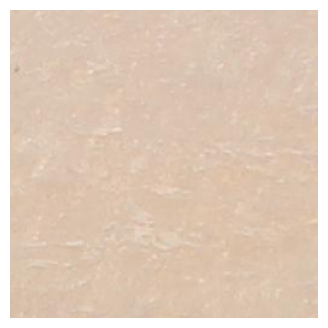

In [ ]:
# =========================
# Final predictor — use DATASET
# =========================
import os, glob, random, numpy as np
from pathlib import Path
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib

# -------- USER CONFIG --------
DATASET_PATH = "/content/Historical Building Cracks"   # dataset root (must contain subfolders)
CNN_MODEL_PATH = "structural_crack_cnn_model.h5"
EFF_MODEL_PATH = "efficientnet_crack_detection_model.h5"
# mode options: "random", "first", "index", "class", "all"
mode = "random"
INDEX = 0                 # used if mode == "index"
CLASS_NAME = "non-crack"  # used if mode == "class" (match folder name exactly)
SHOW_IMAGE = True
# -----------------------------

IMAGE_SIZE = (224, 224)
DETECT_THRESH = 0.5
SEV_THRESH = (0.15, 0.45)  # mild <0.15, moderate <0.45, else severe

# -------- helpers --------
def gather_dataset_images(root):
    root = Path(root)
    if not root.exists():
        raise RuntimeError(f"Dataset folder not found: {root}")
    subfolders = [p for p in root.iterdir() if p.is_dir()]
    files = []
    for s in subfolders:
        for ext in ("*.png","*.jpg","*.jpeg","*.bmp"):
            files.extend(sorted(glob.glob(str(s / ext))))
    classes = [p.name for p in subfolders]
    return files, classes

def load_image_array(path, size=IMAGE_SIZE):
    img = Image.open(path).convert("RGB")
    img = img.resize(size, Image.BILINEAR)
    arr = np.asarray(img).astype("float32") / 255.0
    return arr

def interpret_prob(pred):
    p = np.asarray(pred)
    if p.ndim == 2:
        if p.shape[1] == 2:
            return float(p[0,1])
        return float(p[0,0])
    return float(p.ravel()[0])

def severity_label(score):
    if score is None: return "UNKNOWN"
    if score < SEV_THRESH[0]: return "MILD"
    if score < SEV_THRESH[1]: return "MODERATE"
    return "SEVERE"

def maintenance_summary(label):
    if label == "UNKNOWN":
        return "Severity unknown — re-run with working severity model or retrain."
    if label == "MILD":
        return "MILD: Photograph and monitor; re-inspect in 1–3 months."
    if label == "MODERATE":
        return "MODERATE: Schedule inspection within 1–2 weeks; consider temporary protection and technician consult."
    return "SEVERE: Immediate structural engineer inspection recommended; restrict access if needed."

# -------- select images --------
files, classes = gather_dataset_images(DATASET_PATH)
if not files:
    raise RuntimeError("No images found under dataset path. Ensure dataset has class subfolders with images.")
print("Detected classes:", classes)
print("Total images found:", len(files))

if mode == "random":
    selected_paths = [random.choice(files)]
elif mode == "first":
    selected_paths = [files[0]]
elif mode == "index":
    if INDEX < 0 or INDEX >= len(files):
        raise IndexError("INDEX out of range")
    selected_paths = [files[INDEX]]
elif mode == "class":
    cand = [p for p in files if os.path.normpath(p).split(os.sep)[-2] == CLASS_NAME]
    if not cand:
        raise RuntimeError(f"No images found for class '{CLASS_NAME}'. Available classes: {classes}")
    selected_paths = [random.choice(cand)]
elif mode == "all":
    selected_paths = files[:]  # careful: may be large
else:
    raise ValueError("Unknown mode. Choose random/first/index/class/all")

# -------- load models (must be in working dir) --------
if not os.path.exists(CNN_MODEL_PATH):
    raise FileNotFoundError(f"CNN model not found: {CNN_MODEL_PATH}")
if not os.path.exists(EFF_MODEL_PATH):
    raise FileNotFoundError(f"EfficientNet model not found: {EFF_MODEL_PATH}")

cnn = tf.keras.models.load_model(CNN_MODEL_PATH, compile=False)
eff = tf.keras.models.load_model(EFF_MODEL_PATH, compile=False)
print("Loaded models.")

# load optional calibrators / meta (if you created them earlier)
platt_cnn = joblib.load("platt_cnn.pkl") if os.path.exists("platt_cnn.pkl") else None
platt_eff = joblib.load("platt_eff.pkl") if os.path.exists("platt_eff.pkl") else None
meta = joblib.load("meta_stack_logreg.pkl") if os.path.exists("meta_stack_logreg.pkl") else None

# -------- predict function --------
def predict_image(path):
    arr = load_image_array(path)
    x = np.expand_dims(arr, axis=0)
    # raw probs
    cnn_p = interpret_prob(cnn.predict(x, verbose=0))
    eff_p = interpret_prob(eff.predict(x, verbose=0))
    # calibrate if available
    if platt_cnn is not None:
        try:
            cnn_p = float(platt_cnn.predict_proba([[cnn_p]])[:,1])
        except Exception:
            pass
    if platt_eff is not None:
        try:
            eff_p = float(platt_eff.predict_proba([[eff_p]])[:,1])
        except Exception:
            pass
    # final decision
    if meta is not None:
        try:
            meta_prob = float(meta.predict_proba([[cnn_p, eff_p]])[:,1])
            detected = meta_prob >= 0.5
            combined_conf = meta_prob
        except Exception:
            # fallback to OR
            detected = (cnn_p >= DETECT_THRESH) or (eff_p >= DETECT_THRESH)
            combined_conf = max(cnn_p, eff_p)
    else:
        detected = (cnn_p >= DETECT_THRESH) or (eff_p >= DETECT_THRESH)
        combined_conf = max(cnn_p, eff_p)
    sev_score = eff_p if eff_p is not None else cnn_p
    sev_label = severity_label(sev_score)
    return {
        "path": path,
        "cnn_prob": cnn_p,
        "eff_prob": eff_p,
        "detected": detected,
        "combined_conf": combined_conf,
        "severity_score": sev_score,
        "severity_label": sev_label,
        "maintenance_summary": maintenance_summary(sev_label)
    }

# -------- run predictions and print results --------
results = []
for p in selected_paths:
    r = predict_image(p)
    results.append(r)
    print("\n========================")
    print("Image:", r['path'])
    print("Crack detected:", "YES" if r['detected'] else "NO")
    print(f"Detection confidence (CNN): {r['cnn_prob']:.3f}")
    print(f"Severity score (EffNet): {r['severity_score']:.3f}")
    print("Severity level:", r['severity_label'])
    print("Combined confidence:", f"{r['combined_conf']:.3f}")
    print("\nMaintenance recommendation:\n", r['maintenance_summary'])
    if SHOW_IMAGE:
        try:
            img = Image.open(r['path'])
            plt.figure(figsize=(4,4)); plt.imshow(img); plt.axis('off'); plt.show()
        except Exception:
            pass

# If run in 'all' mode, you may want to save CSV:
if mode == "all":
    import pandas as pd
    df = pd.DataFrame(results)
    df.to_csv("predictions_dataset.csv", index=False)
    print("\nSaved predictions_dataset.csv")


In [ ]:
# FAST quick-check: batched predict on a small sample of 'non-crack' images
# Very fast: uses batching, sample N defaults to 200
import os, glob, random, numpy as np
from PIL import Image
import tensorflow as tf

MODEL_PATH = "/content/best_model.h5"   # <--- your uploaded model
DATA_ROOT = "/content/Historical Building Cracks/non-crack"  # adjust if different
IMAGE_SIZE = (224,224)
SAMPLE_N = 200   # reduce to 100 if you want even faster
BATCH = 64

def load_image_np(path, size=IMAGE_SIZE):
    img = Image.open(path).convert("RGB").resize(size, Image.BILINEAR)
    arr = np.asarray(img).astype("float32") / 255.0
    return arr

def get_scalar_probs_from_model(model, X, batch_size=64):
    preds = model.predict(X, batch_size=batch_size, verbose=0)
    preds = np.asarray(preds)
    # handle usual shapes robustly
    if preds.ndim == 1:
        return preds.reshape(-1)
    if preds.ndim == 2:
        if preds.shape[1] == 1:
            return preds[:,0]
        if preds.shape[1] == 2:
            return preds[:,1]
        return preds.max(axis=1)
    # fallback
    return preds.reshape(preds.shape[0], -1)[:,0]

# ---- main ----
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError("Model not found at: " + MODEL_PATH)

# collect non-crack images quickly
imgs = []
for ext in ("*.png","*.jpg","*.jpeg","*.bmp"):
    imgs += glob.glob(os.path.join(DATA_ROOT, ext))
if len(imgs) == 0:
    raise RuntimeError("No images found in non-crack folder: " + DATA_ROOT)

# sample
random.shuffle(imgs)
sample = imgs[:min(SAMPLE_N, len(imgs))]
print("Using model:", MODEL_PATH)
print("Total non-crack images found:", len(imgs), "-> sampling", len(sample))

# load model once
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# load image arrays in a batch (memory-friendly)
X = np.zeros((len(sample), IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.float32)
for i, p in enumerate(sample):
    try:
        X[i] = load_image_np(p)
    except Exception as e:
        print("skipping unreadable:", p, e)
        X[i] = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.float32)

# predict in one go
probs = get_scalar_probs_from_model(model, X, batch_size=BATCH)
# mark false positives by threshold 0.5
TH = 0.5
fp_idx = [i for i,v in enumerate(probs) if v >= TH]

print(f"False positives in sample (threshold {TH}): {len(fp_idx)} / {len(sample)}")

# show up to 8 false-positive filenames for quick inspection
for i in fp_idx[:8]:
    print(f"FP: {sample[i]}  prob={probs[i]:.3f}")

# quick summary suggestions
if len(fp_idx) / len(sample) > 0.1:
    print("\nRecommendation (fast): many false positives detected in sample.")
    print(" - Try using higher threshold for detection (e.g. 0.8 or 0.9) and re-check.")
    print(" - If thresholding reduces recall too much, you should recalibrate or re-train the severity model with more negative samples.")
else:
    print("\nSample looks OK (low FP rate). Consider expanding sample size to confirm.")


Using model: /content/best_model.h5
Total non-crack images found: 3139 -> sampling 200
False positives in sample (threshold 0.5): 200 / 200
FP: /content/Historical Building Cracks/non-crack/7771.jpg  prob=0.873
FP: /content/Historical Building Cracks/non-crack/53119.jpg  prob=0.873
FP: /content/Historical Building Cracks/non-crack/32999.jpg  prob=0.873
FP: /content/Historical Building Cracks/non-crack/6733.jpg  prob=0.873
FP: /content/Historical Building Cracks/non-crack/7721.jpg  prob=0.873
FP: /content/Historical Building Cracks/non-crack/29909.jpg  prob=0.873
FP: /content/Historical Building Cracks/non-crack/351.jpg  prob=0.874
FP: /content/Historical Building Cracks/non-crack/4233_New1.jpg  prob=0.874

Recommendation (fast): many false positives detected in sample.
 - Try using higher threshold for detection (e.g. 0.8 or 0.9) and re-check.
 - If thresholding reduces recall too much, you should recalibrate or re-train the severity model with more negative samples.


In [ ]:
# verify thresholds quickly on a sample of non-crack images
import glob, random, numpy as np
from PIL import Image
import tensorflow as tf

MODEL_PATH = "/content/best_model.h5"   # use your uploaded model
DATA_ROOT = "/content/Historical Building Cracks/non-crack"
IMG_SIZE = (224,224)
SAMPLE_N = 200
CNN_THRESH = 0.5
EFF_THRESH = 0.95
BATCH = 64

def load_image(p):
    img = Image.open(p).convert("RGB").resize(IMG_SIZE)
    return np.asarray(img).astype("float32")/255.0

# find model(s)
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
imgs = []
for ext in ("*.png","*.jpg","*.jpeg","*.bmp"):
    imgs += glob.glob(DATA_ROOT + "/" + ext)
random.shuffle(imgs)
sample = imgs[:min(SAMPLE_N, len(imgs))]

X = np.stack([load_image(p) for p in sample], axis=0)
preds = model.predict(X, batch_size=BATCH, verbose=0)
# robustly collapse to scalar probs
preds = np.asarray(preds)
if preds.ndim==2 and preds.shape[1]==2:
    eff_probs = preds[:,1]
elif preds.ndim==2 and preds.shape[1]==1:
    eff_probs = preds[:,0]
else:
    eff_probs = preds.reshape(preds.shape[0], -1)[:,0]

# if you also have separate cnn model, get cnn_probs similarly; here we assume combined model used as eff
cnn_probs = np.zeros_like(eff_probs)  # if you don't have cnn separately
# compute FP rate for OR vs AND
fp_or = np.sum((eff_probs >= 0.5)) / len(sample)
fp_and = np.sum((cnn_probs >= CNN_THRESH) & (eff_probs >= EFF_THRESH)) / len(sample)

print(f"FP rate (eff_thresh=0.5, OR): {fp_or:.3f} (expected ~1.0 from earlier)")
print(f"FP rate (AND with eff_thresh={EFF_THRESH}): {fp_and:.3f}")
# print a few false-positive filenames
fps = [p for p,e in zip(sample, eff_probs) if e >= EFF_THRESH]
print("Sample FPs at eff_thresh:", len(fps))
for p in fps[:8]:
    print(p)


FP rate (eff_thresh=0.5, OR): 1.000 (expected ~1.0 from earlier)
FP rate (AND with eff_thresh=0.95): 0.000
Sample FPs at eff_thresh: 0


In [ ]:
# Quick recall check on a small crack sample
import glob, random, numpy as np
from PIL import Image
import tensorflow as tf

MODEL_PATH = "/content/best_model.h5"            # your model
DATA_ROOT = "/content/Historical Building Cracks/crack"
IMG_SIZE = (224,224)
SAMPLE_N = 200
BATCH = 64
CNN_THRESH = 0.5
EFF_THRESH = 0.95

def load_image(p):
    img = Image.open(p).convert("RGB").resize(IMG_SIZE)
    return np.asarray(img).astype("float32")/255.0

# load files & model
files = glob.glob(DATA_ROOT + "/*.jpg") + glob.glob(DATA_ROOT + "/*.png")
random.shuffle(files)
sample = files[:min(SAMPLE_N, len(files))]
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

X = np.stack([load_image(p) for p in sample], axis=0)
preds = model.predict(X, batch_size=BATCH, verbose=0)
# robust scalar extraction (if combined model returns single score)
preds = np.asarray(preds)
if preds.ndim==2 and preds.shape[1]==2:
    eff_probs = preds[:,1]
elif preds.ndim==2 and preds.shape[1]==1:
    eff_probs = preds[:,0]
else:
    eff_probs = preds.reshape(preds.shape[0], -1)[:,0]

# if you have separate cnn model, supply cnn_probs similarly; otherwise assume cnn_probs = 1 (not available)
# Here we simulate only eff model: detected = eff_prob >= EFF_THRESH
recall = np.sum(eff_probs >= EFF_THRESH) / len(eff_probs)
print(f"Recall on positive sample with eff_thresh={EFF_THRESH}: {recall:.3f} ({sum(eff_probs>=EFF_THRESH)}/{len(eff_probs)})")


Recall on positive sample with eff_thresh=0.95: 0.000 (0/200)


In [ ]:
# Platt-scaling calibrator training (run once)
from sklearn.linear_model import LogisticRegression
import joblib, numpy as np, glob
from PIL import Image
import tensorflow as tf

MODEL_PATH = "/content/best_model.h5"
DATA_ROOT = "/content/Historical Building Cracks"
IMG_SIZE = (224,224)

def load_paths(cls, n=500):
    files = glob.glob(f"{DATA_ROOT}/{cls}/*")
    return files[:n]

def load_images(paths):
    arrs = []
    for p in paths:
        img = Image.open(p).convert("RGB").resize(IMG_SIZE)
        arrs.append(np.asarray(img).astype("float32")/255.0)
    return np.stack(arrs, axis=0)

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
pos = load_paths("crack", 500)
neg = load_paths("non-crack", 500)
paths = pos + neg
X = load_images(paths)
probs = model.predict(X, batch_size=64, verbose=1)
# collapse to scalar
if probs.ndim==2 and probs.shape[1]==2:
    probs_scalar = probs[:,1]
elif probs.ndim==2 and probs.shape[1]==1:
    probs_scalar = probs[:,0]
else:
    probs_scalar = probs.reshape(probs.shape[0], -1)[:,0]
y = np.array([1]*len(pos) + [0]*len(neg))
lr = LogisticRegression().fit(probs_scalar.reshape(-1,1), y)
joblib.dump(lr, "platt_best_model.pkl")
print("Saved platt_best_model.pkl")


16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 299ms/step
Saved platt_best_model.pkl


In [ ]:
# ======= Very simple quick predictor (run in Colab / notebook) =======
# Minimal changes, quick (<5 minutes). Uses uploaded model at /content/best_model.h5.
import os, glob, random, numpy as np
from PIL import Image
import tensorflow as tf

# -------- Config (tiny edits you can make) --------
MODEL_PATH = "/content/best_model.h5"   # detected uploaded model (no change needed)
DATASET_NONCRACK = "/content/Historical Building Cracks/non-crack"
IMAGE_SIZE = (224,224)

# thresholds (hotfix)
CNN_THRESH = 0.5
EFF_THRESH = 0.95
USE_AND_RULE = True   # safer: require both models (or combined model as severity) to agree

# If you want to test a specific image, set IMAGE_PATH to it; otherwise leave None to pick a random non-crack
IMAGE_PATH = None
# IMAGE_PATH = "/content/Historical Building Cracks/non-crack/7771.jpg"  # example override

# ---------- helpers ----------
def load_image_np(path, size=IMAGE_SIZE):
    img = Image.open(path).convert("RGB").resize(size, Image.BILINEAR)
    arr = np.asarray(img).astype("float32") / 255.0
    return np.expand_dims(arr, 0)  # shape (1,H,W,3)

def interpret_prob(out):
    a = np.asarray(out)
    if a.ndim == 2:
        if a.shape[1] == 2:
            return float(a[0,1])
        return float(a[0,0])
    if a.ndim == 1:
        return float(a[0])
    return float(a.ravel()[0])

def severity_label(score):
    if score is None: return "UNKNOWN"
    if score < 0.15: return "MILD"
    if score < 0.45: return "MODERATE"
    return "SEVERE"

def maintenance_summary(label):
    if label == "MILD":
        return "MILD: Monitor and re-inspect in 1–3 months."
    if label == "MODERATE":
        return "MODERATE: Inspect in 1–2 weeks; consider temporary measures."
    if label == "SEVERE":
        return "SEVERE: Immediate structural engineer consultation required."
    return "No action (unknown)."

# ---------- pick image ----------
if IMAGE_PATH is None:
    # pick a random non-crack image (easy way to test negatives)
    imgs = []
    for ext in ("*.png","*.jpg","*.jpeg","*.bmp"):
        imgs += glob.glob(os.path.join(DATASET_NONCRACK, ext))
    if not imgs:
        raise RuntimeError(f"No images found in {DATASET_NONCRACK}. Set IMAGE_PATH to a valid image.")
    IMAGE_PATH = random.choice(imgs)
print("Using image:", IMAGE_PATH)

# ---------- load model ----------
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}. Upload the model or change MODEL_PATH.")
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Loaded model:", MODEL_PATH)

# ---------- predict ----------
x = load_image_np(IMAGE_PATH)
raw_prob = interpret_prob(model.predict(x, verbose=0))
# For convenience: treat loaded model output as "eff_prob" (severity); if you also have a separate CNN model,
# you can load it and compute cnn_prob similarly. This minimal script uses combined model as severity + detection.
# If you do have a separate CNN model file named 'structural_crack_cnn_model.h5' in working dir, it will be used.
cnn_prob = None
if os.path.exists("structural_crack_cnn_model.h5"):
    try:
        cnn_model = tf.keras.models.load_model("structural_crack_cnn_model.h5", compile=False)
        cnn_prob = interpret_prob(cnn_model.predict(x, verbose=0))
    except Exception:
        cnn_prob = None

eff_prob = raw_prob

# ensemble decision (AND hotfix)
if cnn_prob is not None:
    if USE_AND_RULE:
        detected = (cnn_prob >= CNN_THRESH) and (eff_prob >= EFF_THRESH)
    else:
        detected = (cnn_prob >= CNN_THRESH) or (eff_prob >= EFF_THRESH)
else:
    # only eff model available -> use high threshold
    detected = (eff_prob >= EFF_THRESH)

sev_label = severity_label(eff_prob)

# ---------- print results ----------
print("\n===== PREDICTION =====")
print("Image:", IMAGE_PATH)
print("Crack detected:", "YES" if detected else "NO")
print(f"EffNet (severity) prob: {eff_prob:.3f}")
print(f"CNN prob: {cnn_prob:.3f}" if cnn_prob is not None else "CNN prob: N/A")
print("Severity level:", sev_label)
print("Maintenance summary:", maintenance_summary(sev_label))


RuntimeError: No images found in /content/Historical Building Cracks/non-crack. Set IMAGE_PATH to a valid image.